# 🏦 Stock Price Predictions

## 0. Project Overview

**Analyzing 16 years of stock market data to predict stock price movements of five major tech firms** in the U.S.: Apple, Microsoft, Amazon, Google, and Meta.

### 🎯 Objectives:
1. Conduct **time-series forecasting** to predict future asset behavior - **forecast next month's stock pricing.**
2. **Survival Analysis** to model the time until significant price movement occurs.
3. **Asset Ranking** to list which assets to prioritize

Included stocks: 
1. Apple (AAPL), 
2. Microsoft (MSFT), 
3. Amazon (AMZN), 
4. Google (GOOGL), 
5. Meta (META)

- 🗓️ Temporal Coverage: 2010 to 2026
    - January 1, 2010 to March 18, 2026 = 5,920 days

Context:


Market Research:
- Patterns: https://www.schwab.com/learn/story/how-to-read-stock-charts-and-trading-patterns

### Importing

In [1]:
from helper import *
from functools import partial
import warnings
import pandas as pd
import numpy as np
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
%matplotlib inline
import warnings
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
import lightgbm as lgb
from lightgbm import LGBMRegressor
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from itertools import combinations
from lifelines import CoxPHFitter
from lifelines.utils import concordance_index
from sklearn.preprocessing import StandardScaler

sns.set_style("darkgrid")
sns.set_theme(
    "notebook",
    rc={
        "axes.titlesize": 14,
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "figure.titlesize": 16,
        "figure.titleweight": "bold",
    },
)
sns.set_palette(["green"])

📌 The end date of this project will have a cut-off for consistent and repeatable results to be able to observe model performance.

Cut-off date: March 18, 2026

In [2]:
tickers = ["AAPL", "MSFT", "AMZN", "GOOGL", "META"]
start_date = "2010-01-01"
end_date = "2026-03-18"

In [3]:
df_import = yf.download(
    tickers, start=start_date, end=end_date, interval="1d", auto_adjust=True
)
# df_import.to_csv("dataset/stock_data.csv")
df = df_import.copy()
df.head()

[*********************100%***********************]  5 of 5 completed


Price          Close                                         High          \
Ticker          AAPL    AMZN      GOOGL META       MSFT      AAPL    AMZN   
Date                                                                        
2010-01-04  6.412384  6.6950  15.555865  NaN  23.077383  6.427066  6.8305   
2010-01-05  6.423471  6.7345  15.487361  NaN  23.084841  6.459727  6.7740   
2010-01-06  6.321295  6.6125  15.096946  NaN  22.943172  6.448937  6.7365   
2010-01-07  6.309608  6.5000  14.745495  NaN  22.704563  6.352156  6.6160   
2010-01-08  6.351557  6.6760  14.942070  NaN  22.861145  6.352157  6.6840   

Price                                  ...      Open                          \
Ticker          GOOGL META       MSFT  ...      AAPL    AMZN      GOOGL META   
Date                                   ...                                     
2010-01-04  15.624369  NaN  23.189228  ...  6.395005  6.8125  15.560829  NaN   
2010-01-05  15.582918  NaN  23.189231  ...  6.430063  6.6715  15.566537  NaN   
2010-01-06  15.533776  NaN  23.174319  ...  6.423469  6.7300  15.533776  NaN   
2010-01-07  15.140132  NaN  22.890972  ...  6.344666  6.6005  15.125239  NaN   
2010-01-08  14.972598  NaN  23.025184  ...  6.301219  6.5280  14.693374  NaN   

Price                     Volume                                       
Ticker           MSFT       AAPL       AMZN      GOOGL META      MSFT  
Date                                                                   
2010-01-04  22.831324  493729600  151998000   78169752  NaN  38409100  
2010-01-05  23.002822  601904800  177038000  120067812  NaN  49749600  
2010-01-06  23.025191  552160000  143576000  158988852  NaN  58182400  
2010-01-07  22.838776  477131200  220604000  256315428  NaN  50559700  
2010-01-08  22.577805  447610800  196610000  188783028  NaN  51197400  

[5 rows x 25 columns]

## 1. Data Cleaning

In [4]:
df.shape

(4075, 25)

Working with 4,075 points of data, meaning **4,075 trading days**.

### Data Types

For time series forecasting and other financial modelling processes, it is best if our **Index is in datetime format.**

In [5]:
print("Index data type: ", df.index.dtype)
print("Other Data Types: \n", df.dtypes)

Index data type:  datetime64[ns]
Other Data Types: 
 Price   Ticker
Close   AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
High    AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Low     AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Open    AAPL      float64
        AMZN      float64
        GOOGL     float64
        META      float64
        MSFT      float64
Volume  AAPL        int64
        AMZN        int64
        GOOGL       int64
        META      float64
        MSFT        int64
dtype: object


Minor fix: Uniform all Volume int features to float

In [6]:
df = df.astype(float)
df["Volume"].dtypes

Ticker
AAPL     float64
AMZN     float64
GOOGL    float64
META     float64
MSFT     float64
dtype: object

#### Null Values & Duplicates

In [7]:
df.isna().sum()

Price   Ticker
Close   AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
High    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Low     AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Open    AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
Volume  AAPL        0
        AMZN        0
        GOOGL       0
        META      599
        MSFT        0
dtype: int64

In [8]:
df["Volume"]["META"].first_valid_index()

Timestamp('2012-05-18 00:00:00')

The null values stem from Meta stocks beginning ~2 years later, missing 599 trading days. Meta went public on the stock market with its Initial Public Offering (IPO) on May 18, 2012.

In [9]:
df.duplicated().sum()

np.int64(0)

There are no duplicates present.

### 🔧 Feature Engineering

Adding 2 additional informational features:
1. Daily Returns (Log): analyzing percentage change return of stocks in a day
2. Monthly Volatility: Measure of uncertainty about the returns provided by the stock.

In [10]:
close = df["Close"]
log_ret = np.log(close / close.shift(1))

log_ret.columns = pd.MultiIndex.from_product([["Return"], log_ret.columns])

# monthly volatility 21 day rolling annualized
monthly_vol = log_ret["Return"].rolling(21).std() * np.sqrt(252)
monthly_vol.columns = pd.MultiIndex.from_product([["Volatility"], monthly_vol.columns])

df = pd.concat([df, log_ret, monthly_vol], axis=1)
df.tail()

Close                                                  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT   
Date                                                                     
2026-03-11  260.809998  212.649994  308.700012  654.299805  404.880005   
2026-03-12  255.759995  209.529999  303.549988  637.634094  401.859985   
2026-03-13  250.119995  207.669998  302.279999  613.184998  395.549988   
2026-03-16  252.820007  211.740005  305.559998  627.450012  399.950012   
2026-03-17  254.229996  215.199997  310.920013  622.659973  399.410004   

                  High                                                  ...  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT  ...   
Date                                                                    ...   
2026-03-11  262.130005  217.000000  311.420013  658.556170  409.010010  ...   
2026-03-12  258.950012  211.710007  308.940002  652.940997  406.119995  ...   
2026-03-13  256.329987  210.559998  307.690002  628.631733  404.799988  ...   
2026-03-16  253.889999  212.720001  306.489990  634.750000  400.630005  ...   
2026-03-17  255.130005  215.699997  311.420013  636.549988  404.399994  ...   

              Return                                         Volatility  \
Ticker          AAPL      AMZN     GOOGL      META      MSFT       AAPL   
Date                                                                      
2026-03-11 -0.000077 -0.007869  0.005392  0.001207 -0.002171   0.286327   
2026-03-12 -0.019553 -0.014781 -0.016824 -0.025801 -0.007487   0.292400   
2026-03-13 -0.022299 -0.008917 -0.004193 -0.039098 -0.015827   0.297249   
2026-03-16  0.010737  0.019409  0.010792  0.022997  0.011062   0.248129   
2026-03-17  0.005562  0.016209  0.017390 -0.007663 -0.001351   0.236627   

                                                    
Ticker          AMZN     GOOGL      META      MSFT  
Date                                                
2026-03-11  0.261073  0.240399  0.230542  0.223250  
2026-03-12  0.264813  0.239583  0.244045  0.224408  
2026-03-13  0.261844  0.226142  0.275264  0.218415  
2026-03-16  0.255326  0.229118  0.275346  0.221319  
2026-03-17  0.258090  0.233990  0.271637  0.221323  

[5 rows x 35 columns]

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4075 entries, 2010-01-04 to 2026-03-17
Data columns (total 35 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   (Close, AAPL)        4075 non-null   float64
 1   (Close, AMZN)        4075 non-null   float64
 2   (Close, GOOGL)       4075 non-null   float64
 3   (Close, META)        3476 non-null   float64
 4   (Close, MSFT)        4075 non-null   float64
 5   (High, AAPL)         4075 non-null   float64
 6   (High, AMZN)         4075 non-null   float64
 7   (High, GOOGL)        4075 non-null   float64
 8   (High, META)         3476 non-null   float64
 9   (High, MSFT)         4075 non-null   float64
 10  (Low, AAPL)          4075 non-null   float64
 11  (Low, AMZN)          4075 non-null   float64
 12  (Low, GOOGL)         4075 non-null   float64
 13  (Low, META)          3476 non-null   float64
 14  (Low, MSFT)          4075 non-null   float64
 15  (Open, AAPL)        

### 🔎 Findings
- 4,075 trading day rows of data

## 📊 2. Exploratory Data Analysis

In [12]:
df.head()

Close                                         High          \
Ticker          AAPL    AMZN      GOOGL META       MSFT      AAPL    AMZN   
Date                                                                        
2010-01-04  6.412384  6.6950  15.555865  NaN  23.077383  6.427066  6.8305   
2010-01-05  6.423471  6.7345  15.487361  NaN  23.084841  6.459727  6.7740   
2010-01-06  6.321295  6.6125  15.096946  NaN  22.943172  6.448937  6.7365   
2010-01-07  6.309608  6.5000  14.745495  NaN  22.704563  6.352156  6.6160   
2010-01-08  6.351557  6.6760  14.942070  NaN  22.861145  6.352157  6.6840   

                                       ...    Return                           \
Ticker          GOOGL META       MSFT  ...      AAPL      AMZN     GOOGL META   
Date                                   ...                                      
2010-01-04  15.624369  NaN  23.189228  ...       NaN       NaN       NaN  NaN   
2010-01-05  15.582918  NaN  23.189231  ...  0.001728  0.005883 -0.004413  NaN   
2010-01-06  15.533776  NaN  23.174319  ... -0.016035 -0.018282 -0.025532  NaN   
2010-01-07  15.140132  NaN  22.890972  ... -0.001850 -0.017160 -0.023555  NaN   
2010-01-08  14.972598  NaN  23.025184  ...  0.006626  0.026717  0.013243  NaN   

                     Volatility                       
Ticker          MSFT       AAPL AMZN GOOGL META MSFT  
Date                                                  
2010-01-04       NaN        NaN  NaN   NaN  NaN  NaN  
2010-01-05  0.000323        NaN  NaN   NaN  NaN  NaN  
2010-01-06 -0.006156        NaN  NaN   NaN  NaN  NaN  
2010-01-07 -0.010454        NaN  NaN   NaN  NaN  NaN  
2010-01-08  0.006873        NaN  NaN   NaN  NaN  NaN  

[5 rows x 35 columns]

In [13]:
df.tail()

Close                                                  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT   
Date                                                                     
2026-03-11  260.809998  212.649994  308.700012  654.299805  404.880005   
2026-03-12  255.759995  209.529999  303.549988  637.634094  401.859985   
2026-03-13  250.119995  207.669998  302.279999  613.184998  395.549988   
2026-03-16  252.820007  211.740005  305.559998  627.450012  399.950012   
2026-03-17  254.229996  215.199997  310.920013  622.659973  399.410004   

                  High                                                  ...  \
Ticker            AAPL        AMZN       GOOGL        META        MSFT  ...   
Date                                                                    ...   
2026-03-11  262.130005  217.000000  311.420013  658.556170  409.010010  ...   
2026-03-12  258.950012  211.710007  308.940002  652.940997  406.119995  ...   
2026-03-13  256.329987  210.559998  307.690002  628.631733  404.799988  ...   
2026-03-16  253.889999  212.720001  306.489990  634.750000  400.630005  ...   
2026-03-17  255.130005  215.699997  311.420013  636.549988  404.399994  ...   

              Return                                         Volatility  \
Ticker          AAPL      AMZN     GOOGL      META      MSFT       AAPL   
Date                                                                      
2026-03-11 -0.000077 -0.007869  0.005392  0.001207 -0.002171   0.286327   
2026-03-12 -0.019553 -0.014781 -0.016824 -0.025801 -0.007487   0.292400   
2026-03-13 -0.022299 -0.008917 -0.004193 -0.039098 -0.015827   0.297249   
2026-03-16  0.010737  0.019409  0.010792  0.022997  0.011062   0.248129   
2026-03-17  0.005562  0.016209  0.017390 -0.007663 -0.001351   0.236627   

                                                    
Ticker          AMZN     GOOGL      META      MSFT  
Date                                                
2026-03-11  0.261073  0.240399  0.230542  0.223250  
2026-03-12  0.264813  0.239583  0.244045  0.224408  
2026-03-13  0.261844  0.226142  0.275264  0.218415  
2026-03-16  0.255326  0.229118  0.275346  0.221319  
2026-03-17  0.258090  0.233990  0.271637  0.221323  

[5 rows x 35 columns]

#### 🔎 Features:
- Date - trading day
- Ticker - Stock label to indicate which of the big 5 tech stock

5 features per Date & Ticker:
- Close - close price (adjusted for splits)
- High - maximum price during the day
- Low - lowest price during the day
- Open - first trade price
- Volume - the total number of shares or contracts exchanged in a market within the single trading day

Additional Information:
- Return (%) - Daily return in percent
- Volatility (over 21 days) - rolling return volatility over 21 days


In [14]:
df.describe().T

count          mean           std           min  \
           Ticker                                                     
Close      AAPL    4075.0  7.974878e+01  7.727094e+01  5.754396e+00   
           AMZN    4075.0  8.230980e+01  7.043986e+01  5.430500e+00   
           GOOGL   4075.0  7.332980e+01  6.489387e+01  1.082321e+01   
           META    3476.0  2.258794e+02  1.842458e+02  1.759195e+01   
           MSFT    4075.0  1.527628e+02  1.475091e+02  1.731505e+01   
High       AAPL    4075.0  8.054229e+01  7.803143e+01  5.872748e+00   
           AMZN    4075.0  8.326100e+01  7.125323e+01  5.564500e+00   
           GOOGL   4075.0  7.409290e+01  6.563977e+01  1.097734e+01   
           META    3476.0  2.287175e+02  1.865290e+02  1.812774e+01   
           MSFT    4075.0  1.541528e+02  1.487919e+02  1.754833e+01   
Low        AAPL    4075.0  7.888604e+01  7.644290e+01  5.700461e+00   
           AMZN    4075.0  8.130419e+01  6.959890e+01  5.290000e+00   
           GOOGL   4075.0  7.251582e+01  6.407006e+01  1.076265e+01   
           META    3476.0  2.229535e+02  1.819660e+02  1.741335e+01   
           MSFT    4075.0  1.512447e+02  1.461340e+02  1.710436e+01   
Open       AAPL    4075.0  7.968839e+01  7.720377e+01  5.763984e+00   
           AMZN    4075.0  8.232783e+01  7.047305e+01  5.296500e+00   
           GOOGL   4075.0  7.329677e+01  6.484993e+01  1.087881e+01   
           META    3476.0  2.258615e+02  1.843913e+02  1.793922e+01   
           MSFT    4075.0  1.527381e+02  1.475265e+02  1.737526e+01   
Volume     AAPL    4075.0  2.168677e+08  2.149768e+08  1.791060e+07   
           AMZN    4075.0  8.044675e+07  5.100824e+07  1.142050e+07   
           GOOGL   4075.0  5.468027e+07  4.620418e+07  9.312000e+06   
           META    3476.0  2.813657e+07  2.507180e+07  4.726100e+06   
           MSFT    4075.0  3.531009e+07  2.053952e+07  5.855900e+06   
Return     AAPL    4074.0  9.032912e-04  1.772079e-02 -1.377078e-01   
           AMZN    4074.0  8.517935e-04  2.061794e-02 -1.513979e-01   
           GOOGL   4074.0  7.351738e-04  1.734366e-02 -1.236848e-01   
           META    3475.0  8.052365e-04  2.499685e-02 -3.063906e-01   
           MSFT    4074.0  6.998369e-04  1.614281e-02 -1.594537e-01   
Volatility AAPL    4054.0  2.578430e-01  1.141798e-01  7.239887e-02   
           AMZN    4054.0  3.041519e-01  1.250493e-01  7.747502e-02   
           GOOGL   4054.0  2.548931e-01  1.071213e-01  6.437352e-02   
           META    3455.0  3.500287e-01  1.830312e-01  6.973879e-02   
           MSFT    4054.0  2.344950e-01  1.084663e-01  5.474515e-02   

                            25%           50%           75%           max  
           Ticker                                                          
Close      AAPL    1.840116e+01  3.961630e+01  1.449534e+02  2.859225e+02  
           AMZN    1.557350e+01  6.950000e+01  1.455828e+02  2.540000e+02  
           GOOGL   2.625376e+01  5.203890e+01  1.127938e+02  3.434482e+02  
           META    9.625216e+01  1.725856e+02  2.942632e+02  7.881490e+02  
           MSFT    3.109418e+01  8.278111e+01  2.569251e+02  5.398252e+02  
High       AAPL    1.855709e+01  4.013032e+01  1.461920e+02  2.883502e+02  
           AMZN    1.572025e+01  7.106800e+01  1.474150e+02  2.586000e+02  
           GOOGL   2.647469e+01  5.260473e+01  1.138054e+02  3.487545e+02  
           META    9.738825e+01  1.746296e+02  2.989763e+02  7.943844e+02  
           MSFT    3.124677e+01  8.421098e+01  2.598351e+02  5.522420e+02  
Low        AAPL    1.819334e+01  3.925163e+01  1.431566e+02  2.830352e+02  
           AMZN    1.535000e+01  6.776650e+01  1.436687e+02  2.529000e+02  
           GOOGL   2.599813e+01  5.141803e+01  1.111955e+02  3.372326e+02  
           META    9.461501e+01  1.705367e+02  2.904953e+02  7.789906e+02  
           MSFT    3.082714e+01  8.185267e+01  2.541054e+02  5.385306e+02  
Open       AAPL    1.842271e+01  3.975746e+01  1.449328e+02  2.859325e+02  
           AMZN    1.554

### Date

In [15]:
start_date = df.index[0]
end_date = df.index[-1]
duration = end_date - start_date

print("Start Date:", start_date.date())
print("End Date:", end_date.date())
print("Duration:", duration.days, "days")
print("Amount of Trading Days:", df.shape[0])

Start Date: 2010-01-04
End Date: 2026-03-17
Duration: 5916 days
Amount of Trading Days: 4075


### OHLC Distributions

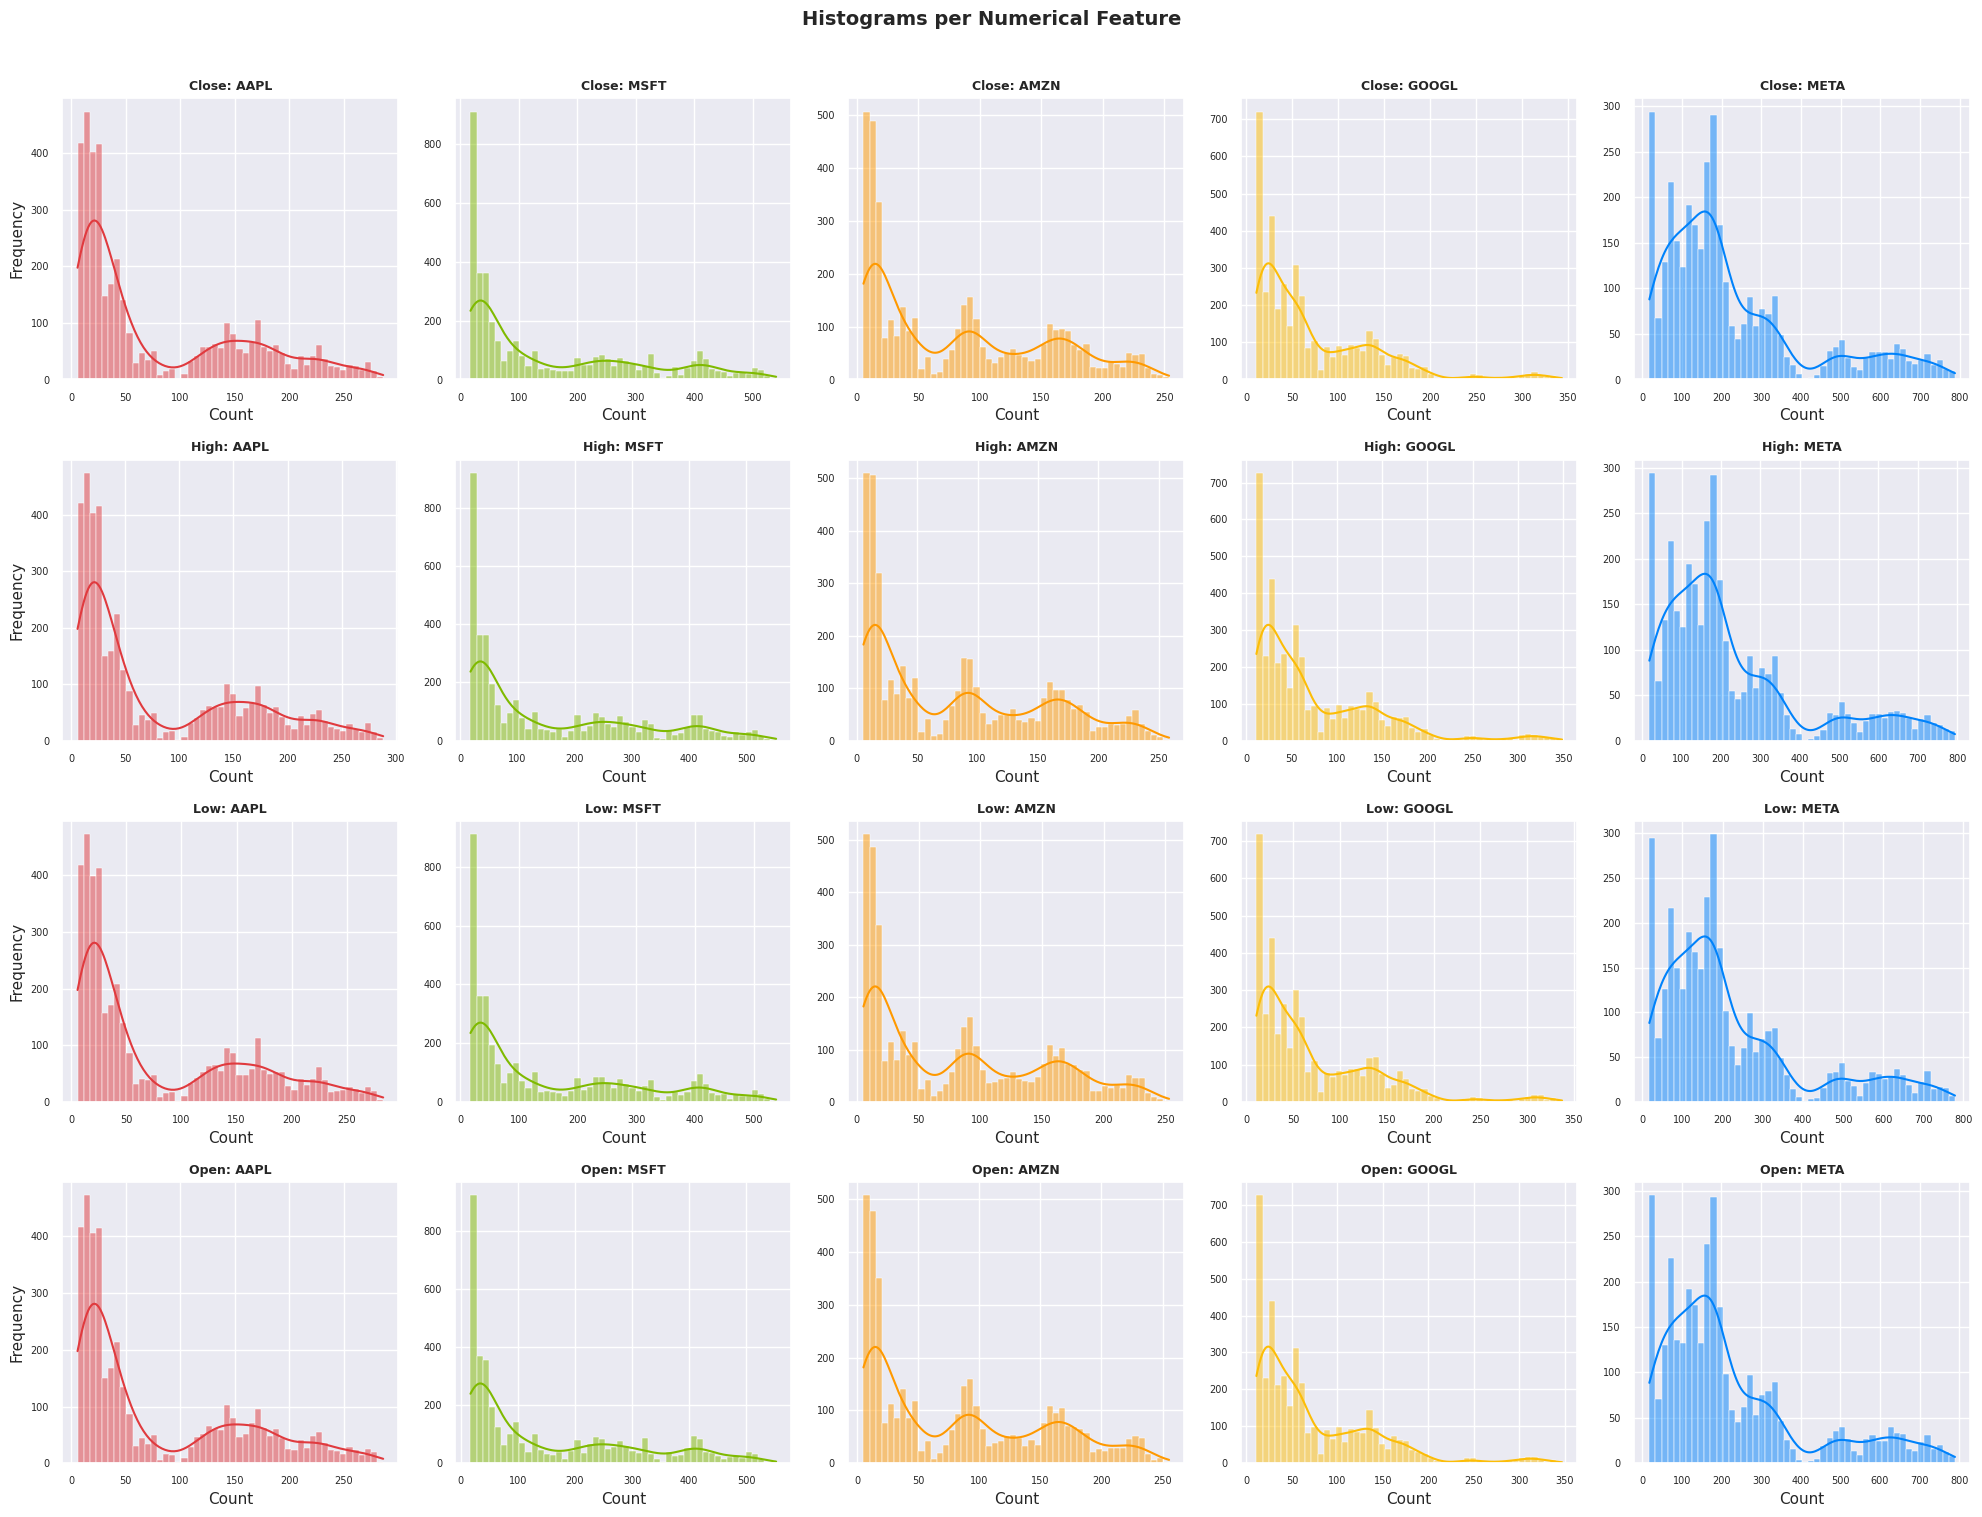

In [16]:
ohlc_cols = ["Close", "High", "Low", "Open"]

logo_palette = {
    "AAPL": "#E03A3E",
    "MSFT": "#7fba00",
    "AMZN": "#ff9900",
    "GOOGL": "#FCBD07",
    "META": "#0082fb",
}

fig, axes = plt.subplots(len(ohlc_cols), len(tickers), figsize=(20, 15))

for i, feature in enumerate(ohlc_cols):
    for j, ticker in enumerate(tickers):
        ax = axes[i][j]
        sns.histplot(
            df[feature][ticker].dropna(),
            bins=50,
            ax=ax,
            kde=True,
            color=logo_palette[ticker],
        )
        ax.set_title(f"{feature}: {ticker}", fontsize=9)
        ax.set_xlabel("Count")
        ax.set_ylabel("Frequency" if j == 0 else "")
        ax.tick_params(labelsize=7)

plt.suptitle("Histograms per Numerical Feature", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### Volume

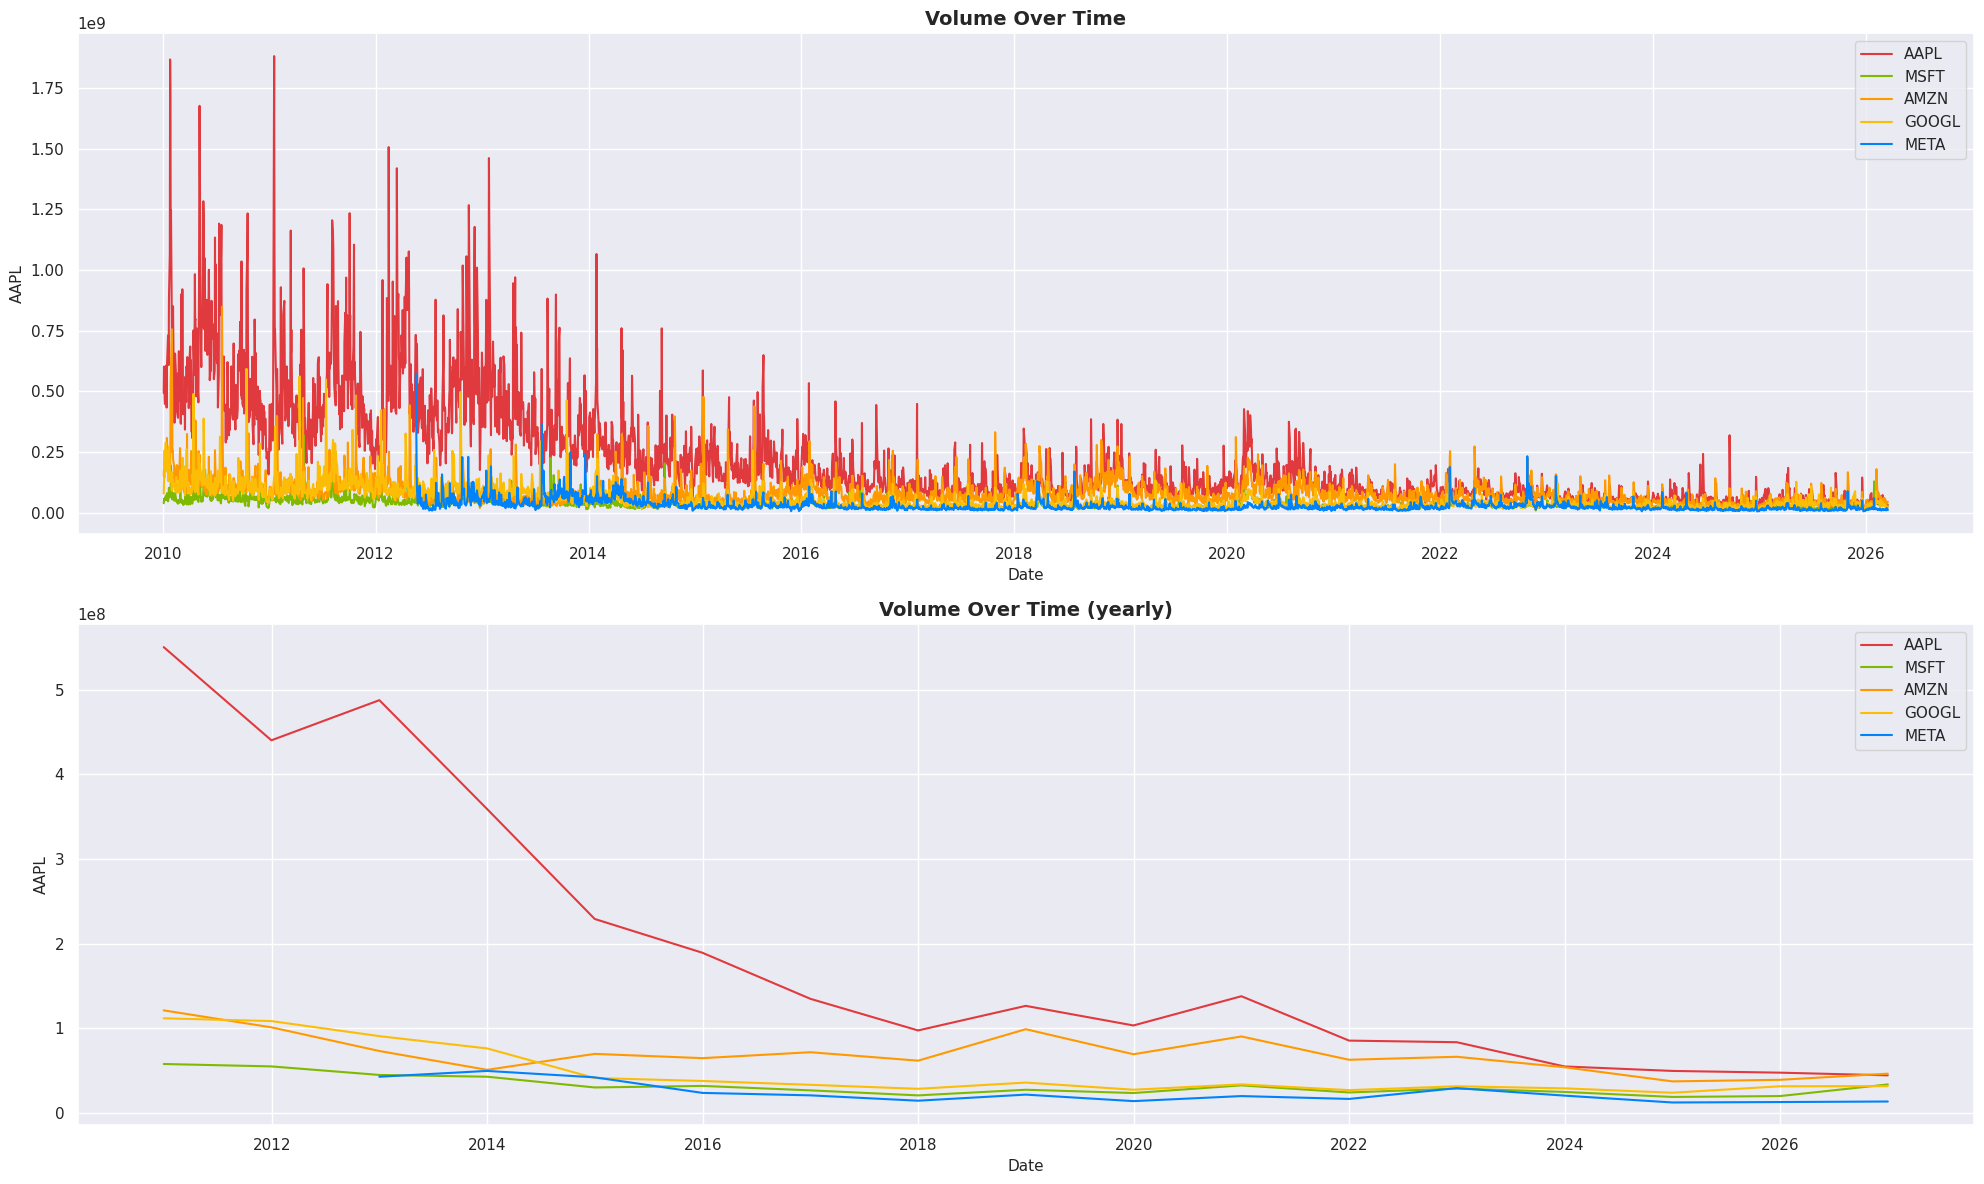

In [17]:
fig, axes = plt.subplots(2, 1, figsize=(20, 12))

for ticker in tickers:
    sns.lineplot(
        data=df["Volume"],
        x=df.index,
        y=ticker,
        color=logo_palette[ticker],
        label=ticker,
        ax=axes[0],
    )
axes[0].set_title("Volume Over Time")
axes[0].tick_params(axis="x", rotation=0)

volume_yearly = df["Volume"].resample("YE").median()[tickers]
for ticker in tickers:
    sns.lineplot(
        data=volume_yearly,
        x=volume_yearly.index,
        y=ticker,
        color=logo_palette[ticker],
        label=ticker,
        ax=axes[1],
    )
axes[1].set_title("Volume Over Time (yearly)")

plt.tight_layout()
plt.show()

### Returns & Volatility

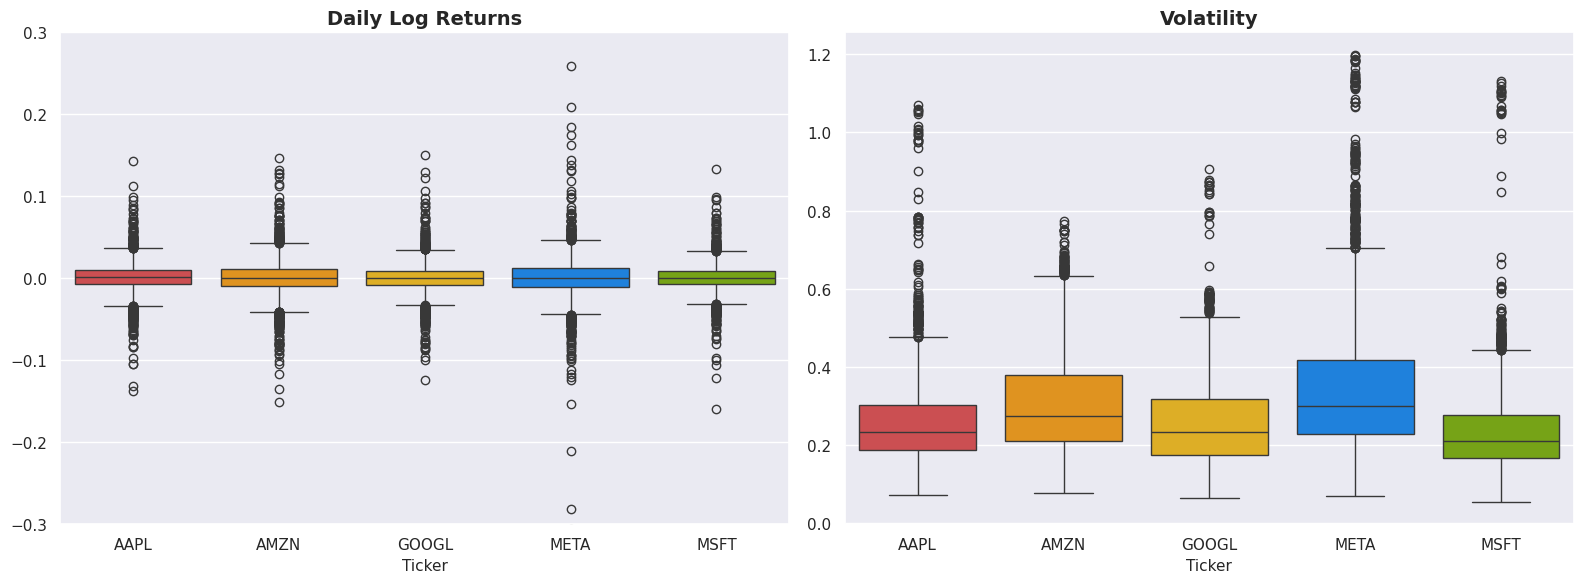

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.boxplot(data=df["Return"], palette=logo_palette, ax=axes[0])
axes[0].set_title("Daily Log Returns")
axes[0].set_ylim(-0.3, 0.3)

sns.boxplot(data=df["Volatility"], palette=logo_palette, ax=axes[1])
axes[1].set_title("Volatility")

plt.tight_layout()
plt.show()

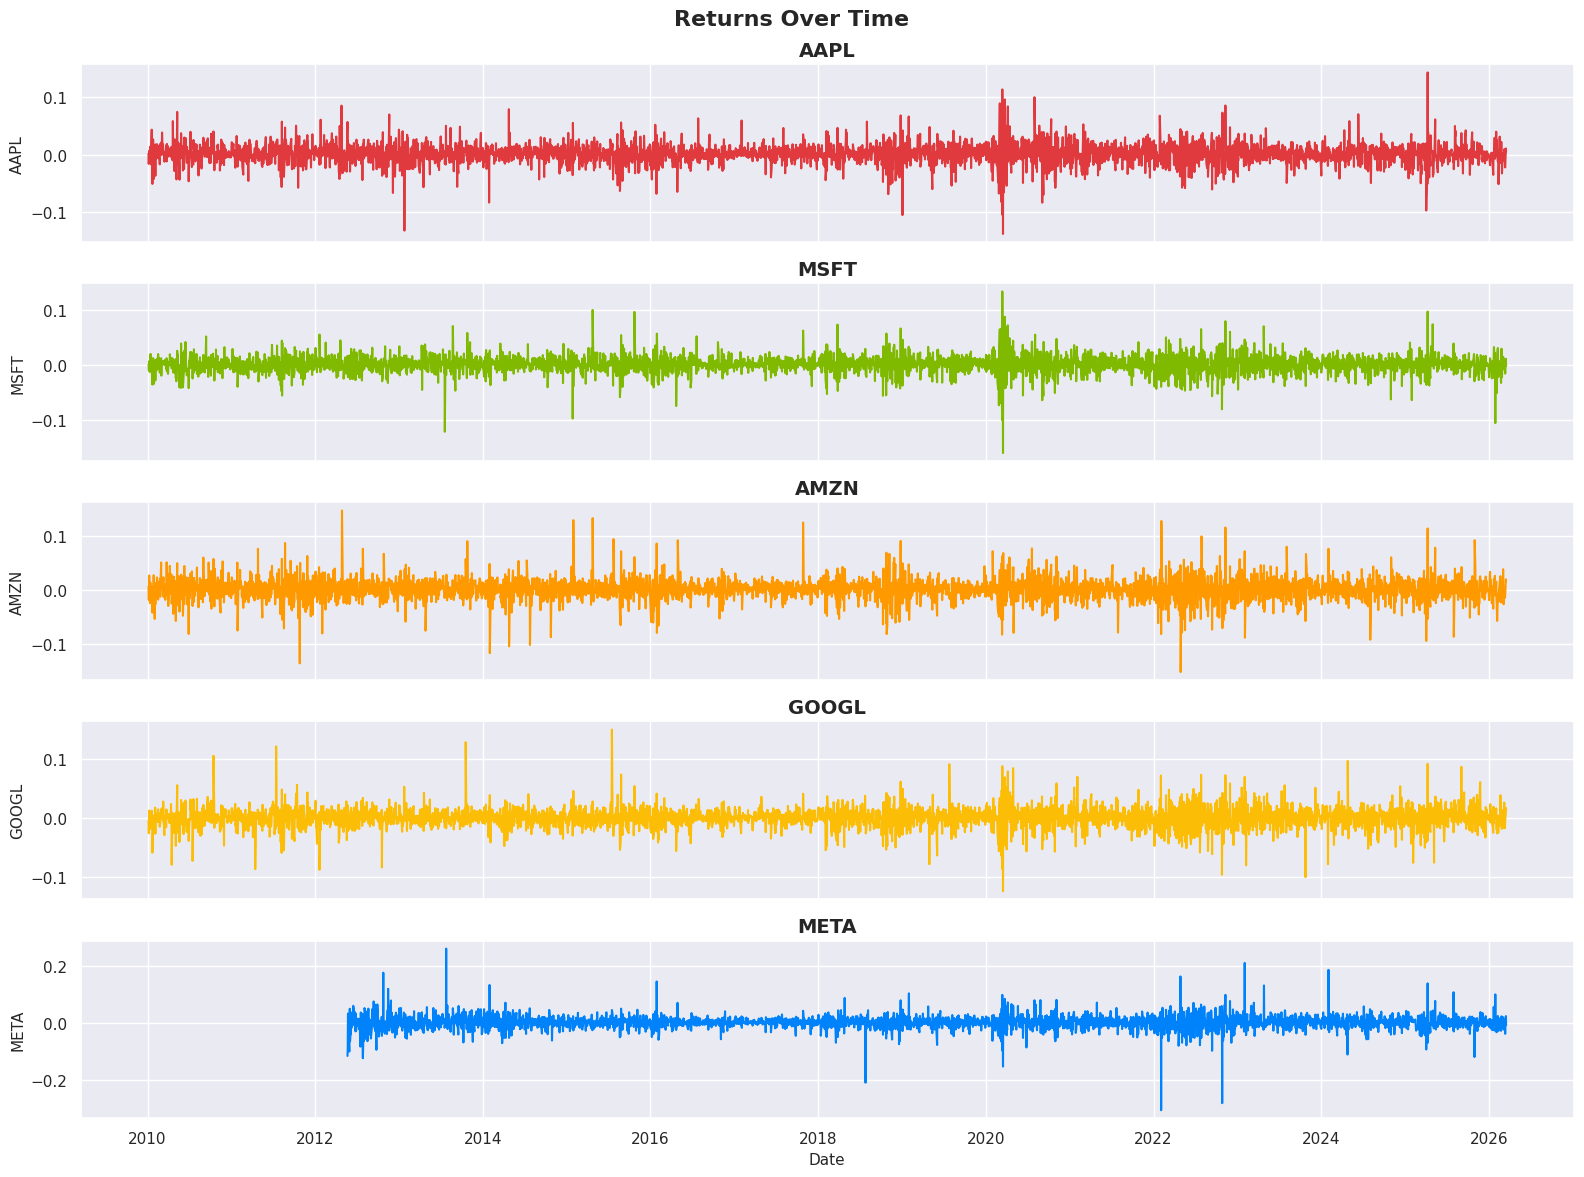

In [19]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(data=df["Return"][ticker], ax=axes[i], color=logo_palette[ticker])
    axes[i].set_title(ticker)

plt.suptitle("Returns Over Time")
plt.tight_layout()
plt.show()

### Volatility

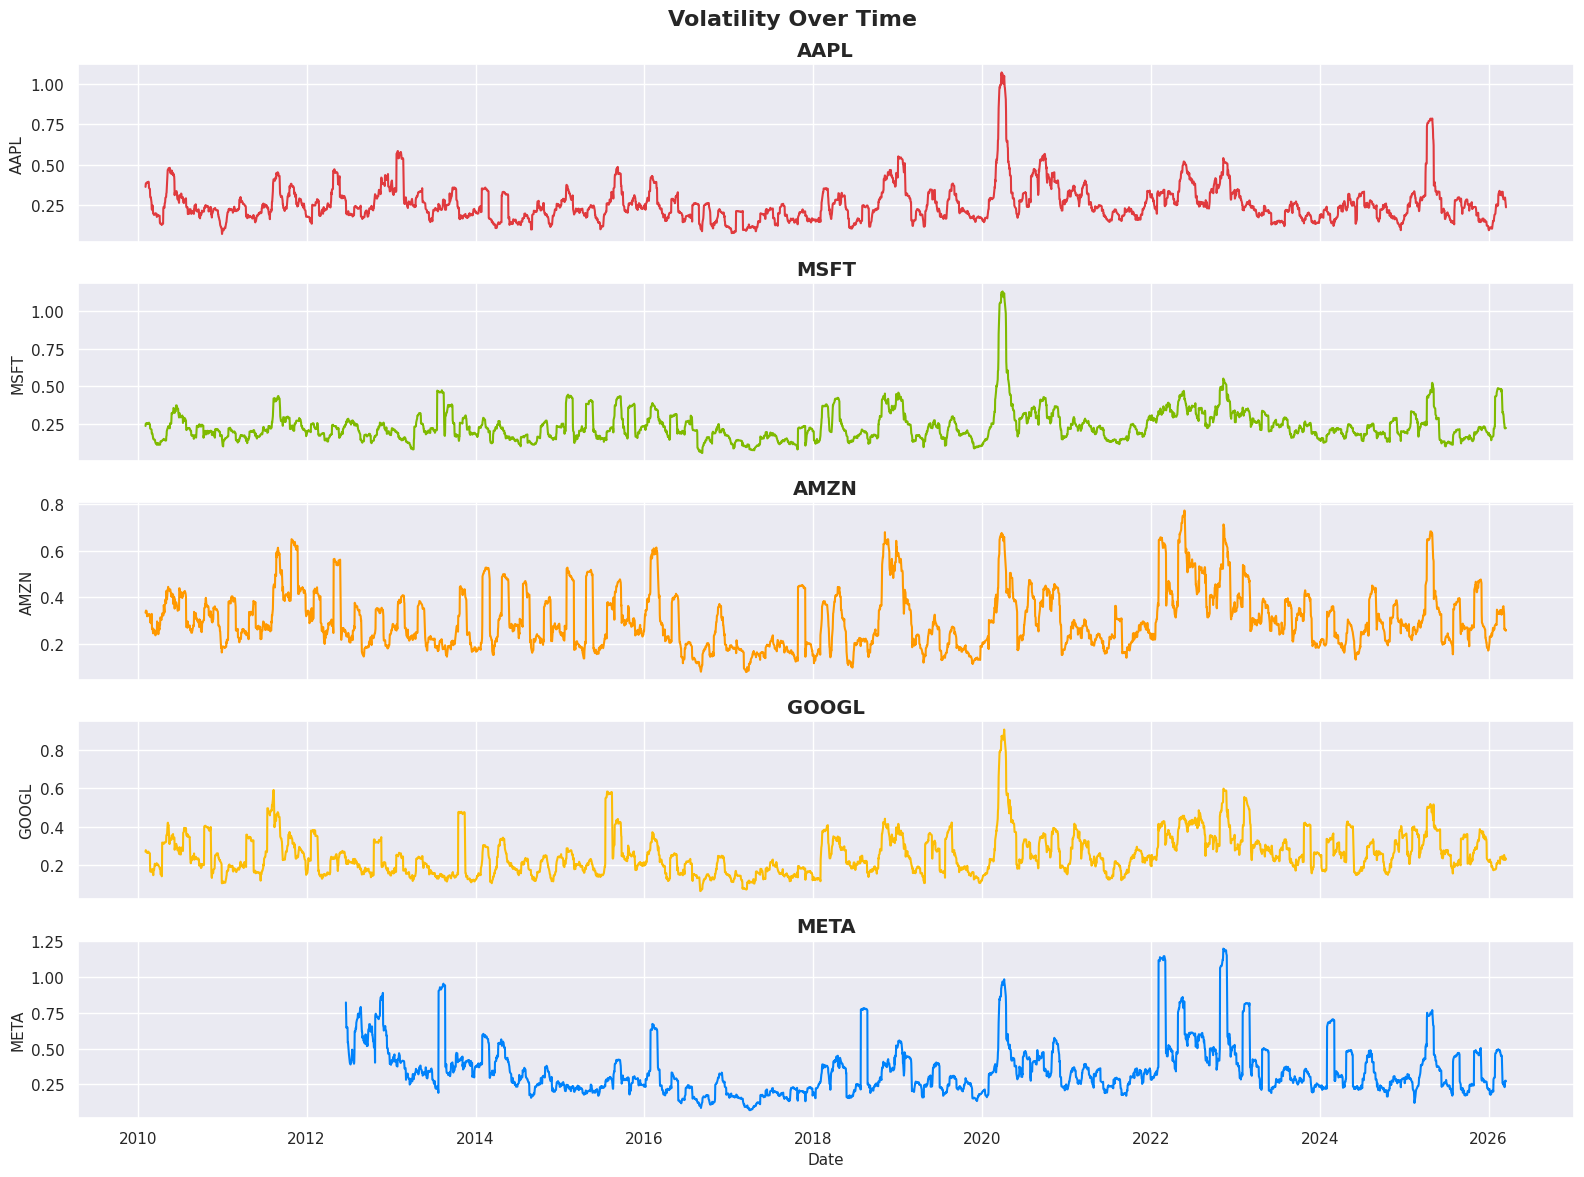

In [20]:
fig, axes = plt.subplots(5, 1, figsize=(16, 12), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(data=df["Volatility"][ticker], ax=axes[i], color=logo_palette[ticker])
    axes[i].set_title(ticker)

plt.suptitle("Volatility Over Time")
plt.tight_layout()
plt.show()

### Close Prices

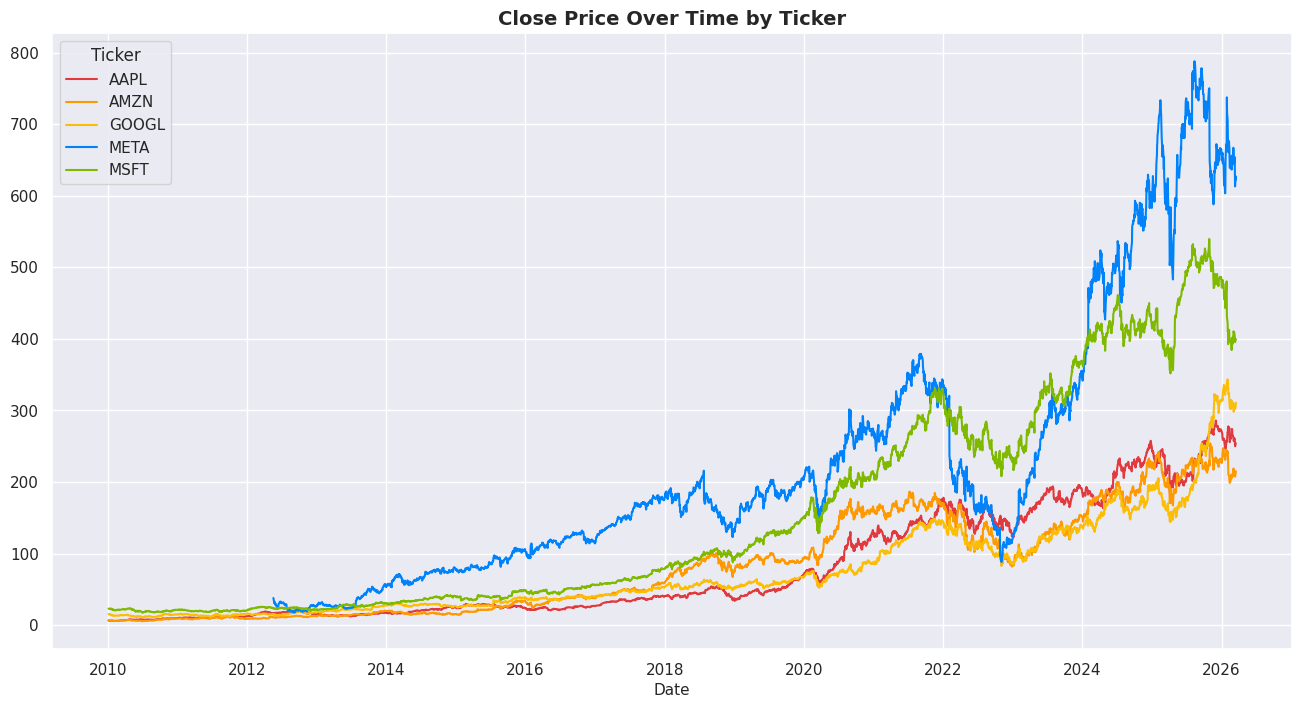

In [21]:
plt.figure(figsize=(16, 8))
sns.lineplot(data=df["Close"], palette=logo_palette, dashes=False)
plt.title("Close Price Over Time by Ticker")
plt.show()

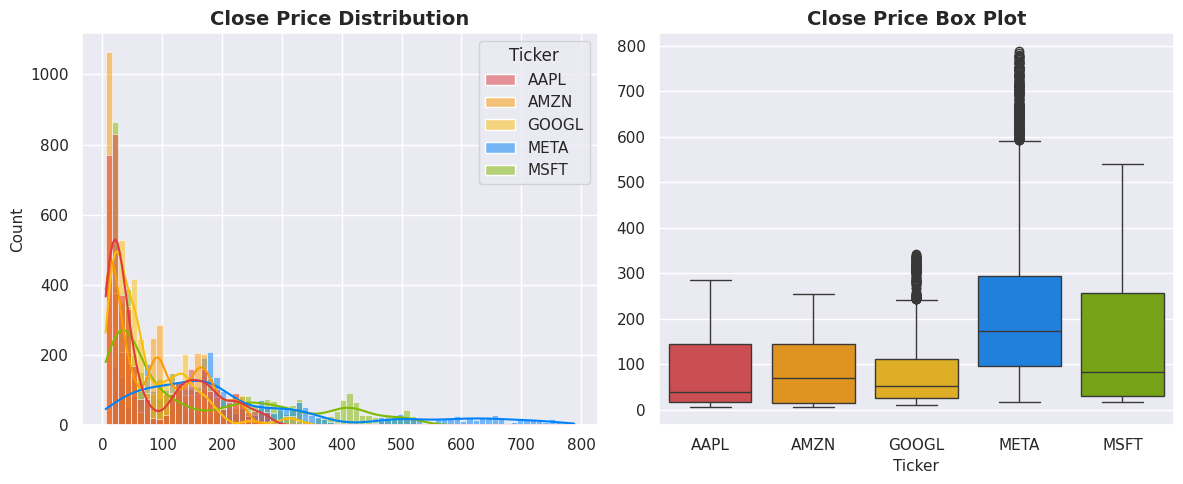

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df["Close"], kde=True, palette=logo_palette, ax=axes[0])
axes[0].set_title("Close Price Distribution")

sns.boxplot(data=df["Close"], palette=logo_palette, ax=axes[1])
axes[1].set_title("Close Price Box Plot")

plt.tight_layout()
plt.show()

### Seasonal Decomposition

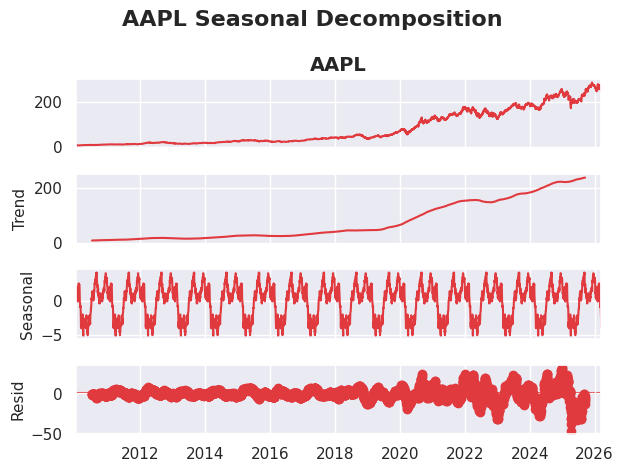

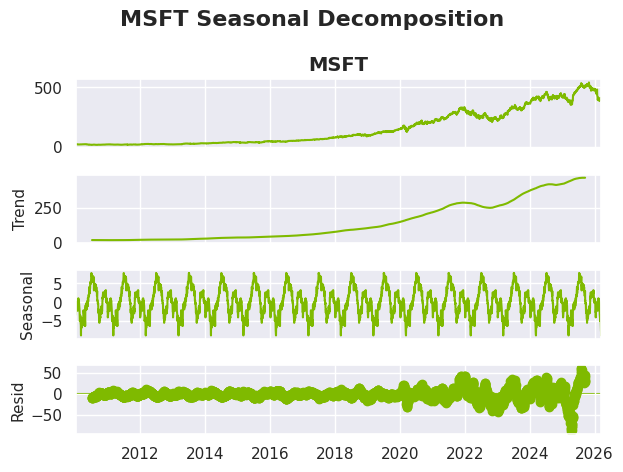

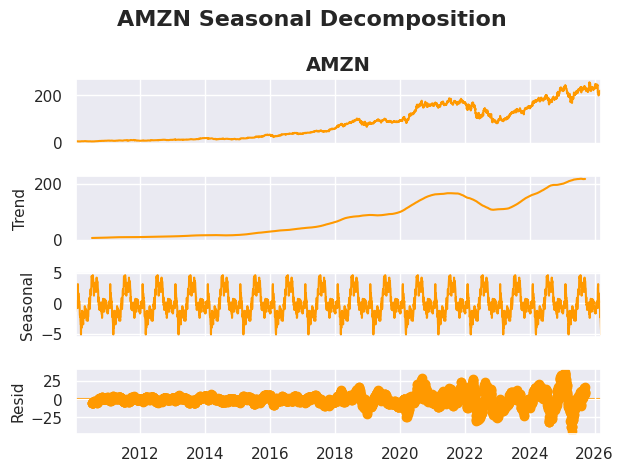

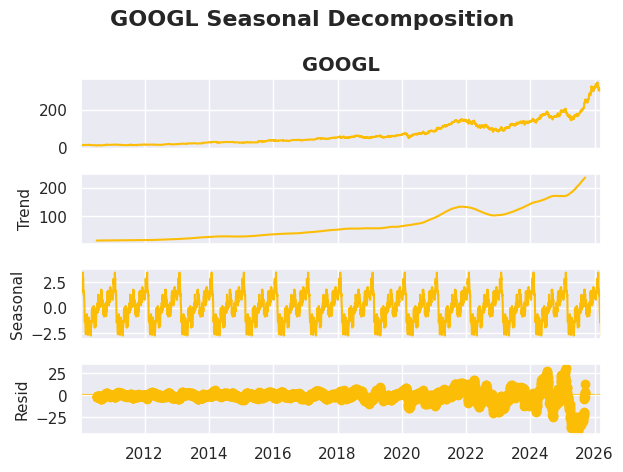

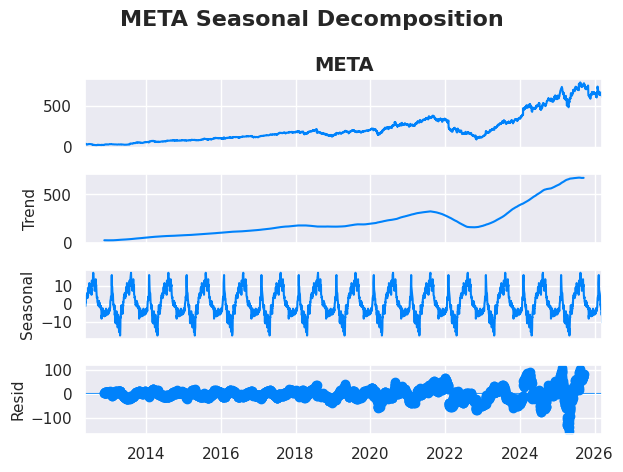

In [23]:
for ticker in tickers:
    series = df["Close"][ticker].dropna()
    decomposition = seasonal_decompose(series, model="additive", period=252)
    fig = decomposition.plot()
    for ax in fig.axes:
        for line in ax.get_lines():
            line.set_color(logo_palette[ticker])
    plt.suptitle(f"{ticker} Seasonal Decomposition")
    plt.tight_layout()
    plt.show()

### Correlations

Numerical Features Correlations

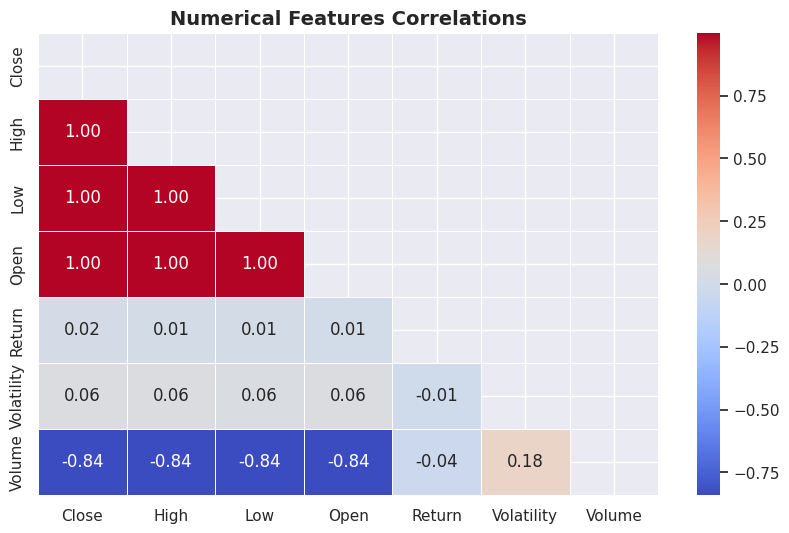

In [24]:
corr = df.T.groupby(level=0).mean().T.corr(method="spearman")
matrix = np.triu(corr)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, mask=matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Numerical Features Correlations")
plt.show()

Return correlations amongst the 5 stocks

Do the 5 stocks move similarly?

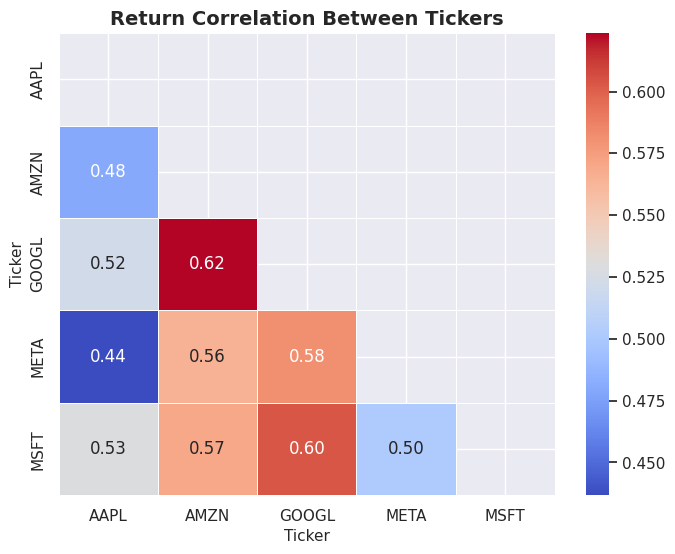

In [25]:
corr = df["Return"].corr(method="spearman")

matrix = np.triu(corr)

plt.figure(figsize=(8, 6))
sns.heatmap(corr, mask=matrix, cmap="coolwarm", annot=True, fmt=".2f", linewidths=0.5)
plt.title("Return Correlation Between Tickers")
plt.show()

## 3. Statistical Inference

> Perform statistical inference. This should include defining the target population, forming multiple statistical hypotheses and constructing confidence intervals, setting the significance levels, and conducting z or t-tests for these hypotheses.


## 📈 4. Time-Series Forecasting
> Build generic time-series model that is capable of predicting next day stock price based on previous patterns. Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

### Stationarity

#### Testing for Stationarity

In [26]:
from statsmodels.tsa.stattools import adfuller

for ticker in tickers:
    result = adfuller(df["Close"][ticker].dropna())
    print(f"{ticker} p-value: {result[1]:.4f}")

AAPL p-value: 0.9918
MSFT p-value: 0.9633
AMZN p-value: 0.9515
GOOGL p-value: 0.9990
META p-value: 0.9561


Data is not stationary, as expected of stock pricing. Differencing will be applied

#### Differencing for Stationarity

In [27]:
common_start = df["Close"].apply(lambda x: x.first_valid_index()).max()

df_close = df["Close"][df["Close"].index >= common_start]
df_diff = df_close.diff().dropna()

for ticker in tickers:
    result = adfuller(df_diff[ticker])
    print(f"{ticker} p-value: {result[1]:.4f}")

AAPL p-value: 0.0000
MSFT p-value: 0.0000
AMZN p-value: 0.0000
GOOGL p-value: 0.0000
META p-value: 0.0000


✅ Significant p-values = 0. Data is now stationary for ARIMA modelling.

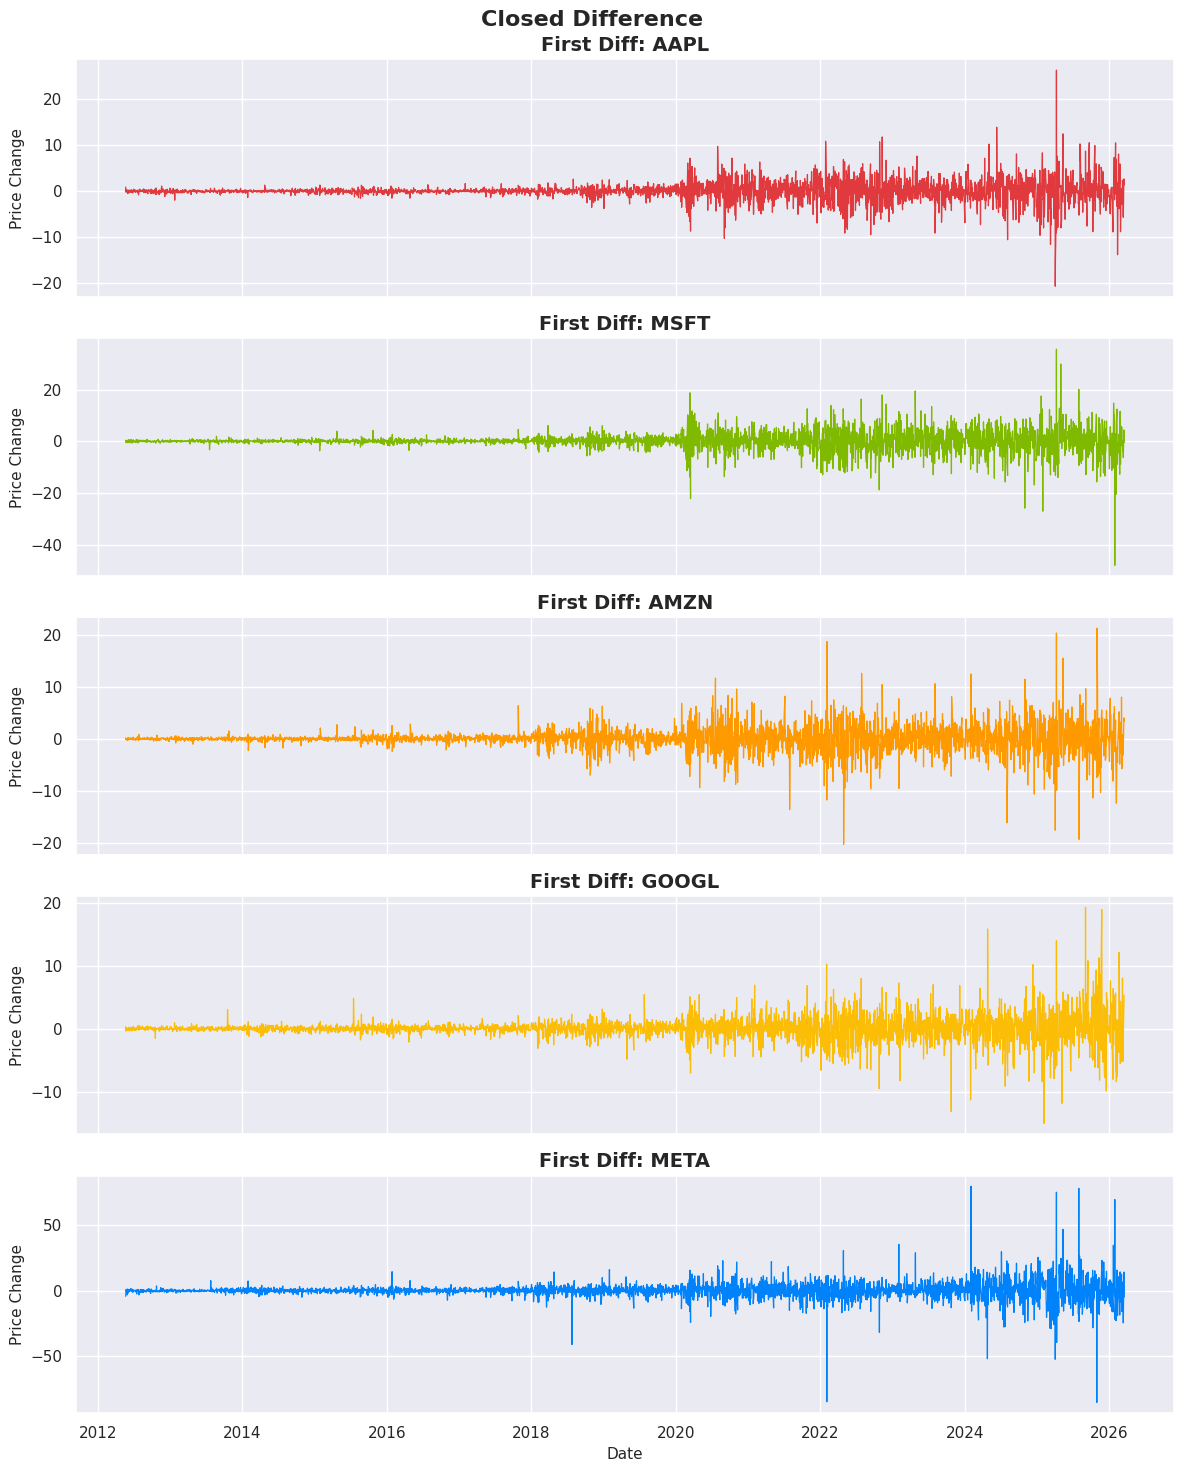

In [28]:
n = len(tickers)
fig, axes = plt.subplots(n, 1, figsize=(12, 3 * n), sharex=True)

for i, ticker in enumerate(tickers):
    sns.lineplot(
        x=df_diff.index,
        y=df_diff[ticker],
        ax=axes[i],
        linewidth=0.9,
        color=logo_palette[ticker],
    )
    axes[i].set_title(f"First Diff: {ticker}")
    axes[i].set_ylabel("Price Change")

plt.suptitle("Closed Difference")
plt.tight_layout()
plt.show()

### Modelling

#### Model 0 Baseline: Moving Average 
Averaging over a fixed window will be give our baseline metrics.

The Moving Average model is a simple yet effective method for time series forecasting. It calculates the average of past observations over a fixed window size and uses this average as the prediction for the next time step. The MA model is suitable for data with no clear trend or seasonality.

In [29]:
results = None

for ticker in tickers:
    results, actuals, preds, folds = walk_forward_validation(
        series=df_diff[ticker].dropna().values,
        model_fn=ma_baseline_model,
        ticker=ticker,
        model_name="MA Baseline",
        results=results,
        series_level=df_close[ticker].values,
        invert_diff=True,
    )

results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,MA Baseline,5.360837,4.573078,4.853202,-0.111392
1,MSFT,MA Baseline,9.361704,8.088076,3.984671,-0.008993
2,AMZN,MA Baseline,6.739314,5.805183,5.732642,-0.023766
3,GOOGL,MA Baseline,5.190102,4.420708,4.542796,-0.137501
4,META,MA Baseline,17.064800,14.782933,6.047188,-0.031262


#### Model 1: SES Model

In [30]:
for ticker in tickers:
    results, actuals, preds, folds = walk_forward_validation(
        series=df_diff[ticker].values,
        model_fn=ses_model,
        ticker=ticker,
        model_name="SES",
        results=results,
        series_level=df_close[ticker].values,
        invert_diff=True,
    )

results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,SES,4.913854,4.186846,4.345920,-0.207707
1,AAPL,MA Baseline,5.360837,4.573078,4.853202,-0.111392
2,AMZN,SES,5.780861,4.951512,4.903944,0.138000
3,AMZN,MA Baseline,6.739314,5.805183,5.732642,-0.023766
4,GOOGL,SES,4.516173,3.838780,4.114766,-0.013312
5,GOOGL,MA Baseline,5.190102,4.420708,4.542796,-0.137501
6,META,SES,16.051011,14.041249,5.666580,0.785803
7,META,MA Baseline,17.064800,14.782933,6.047188,-0.031262
8,MSFT,SES,8.456246,7.307391,3.594011,0.453386
9,MSFT,MA Baseline,9.361704,8.088076,3.984671,-0.008993


#### Model 2: ARIMA Model

training_window=252 (1 trading year) and forecast_horizon=21 (1 trading month) for realistic monthly reforecasting

Rolling fixed window, prevents old data from diluting more recent patterns

Lag features are handled internally

In [31]:
for ticker in tickers:
    results, actuals, preds, folds = walk_forward_validation(
        series=df_diff[ticker].values,
        model_fn=arima_model,
        ticker=ticker,
        model_name="ARIMA",
        results=results,
        series_level=df_close[ticker].values,
        invert_diff=True,
    )

results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,ARIMA,4.738961,4.068580,4.173180,-0.057184
1,AAPL,SES,4.913854,4.186846,4.345920,-0.207707
2,AAPL,MA Baseline,5.360837,4.573078,4.853202,-0.111392
3,AMZN,ARIMA,5.467475,4.695371,4.668503,0.082710
4,AMZN,SES,5.780861,4.951512,4.903944,0.138000
5,AMZN,MA Baseline,6.739314,5.805183,5.732642,-0.023766
6,GOOGL,ARIMA,4.181680,3.577009,3.708370,0.292302
7,GOOGL,SES,4.516173,3.838780,4.114766,-0.013312
8,GOOGL,MA Baseline,5.190102,4.420708,4.542796,-0.137501
9,META,ARIMA,14.548186,12.746716,5.317882,-0.027692


#### Model 3: LGB Model

In [32]:
# for ticker in tickers:
#     results, actuals, preds, folds = walk_forward_validation(
#         series=df_diff[ticker].dropna().values,
#         model_fn=partial(lgbm_model),
#         ticker=ticker,
#         model_name="LGBM",
#         results=results,
#         series_level=df_close[ticker].values,
#         invert_diff=True,
#     )

#### 🏆️ Model Results

In [33]:
results = results.sort_values(["Ticker", "RMSE"]).reset_index(drop=True)
results

,Ticker,Model,RMSE,MAE,MAPE,Forecast Bias
0,AAPL,ARIMA,4.738961,4.068580,4.173180,-0.057184
1,AAPL,SES,4.913854,4.186846,4.345920,-0.207707
2,AAPL,MA Baseline,5.360837,4.573078,4.853202,-0.111392
3,AMZN,ARIMA,5.467475,4.695371,4.668503,0.082710
4,AMZN,SES,5.780861,4.951512,4.903944,0.138000
5,AMZN,MA Baseline,6.739314,5.805183,5.732642,-0.023766
6,GOOGL,ARIMA,4.181680,3.577009,3.708370,0.292302
7,GOOGL,SES,4.516173,3.838780,4.114766,-0.013312
8,GOOGL,MA Baseline,5.190102,4.420708,4.542796,-0.137501
9,META,ARIMA,14.548186,12.746716,5.317882,-0.027692


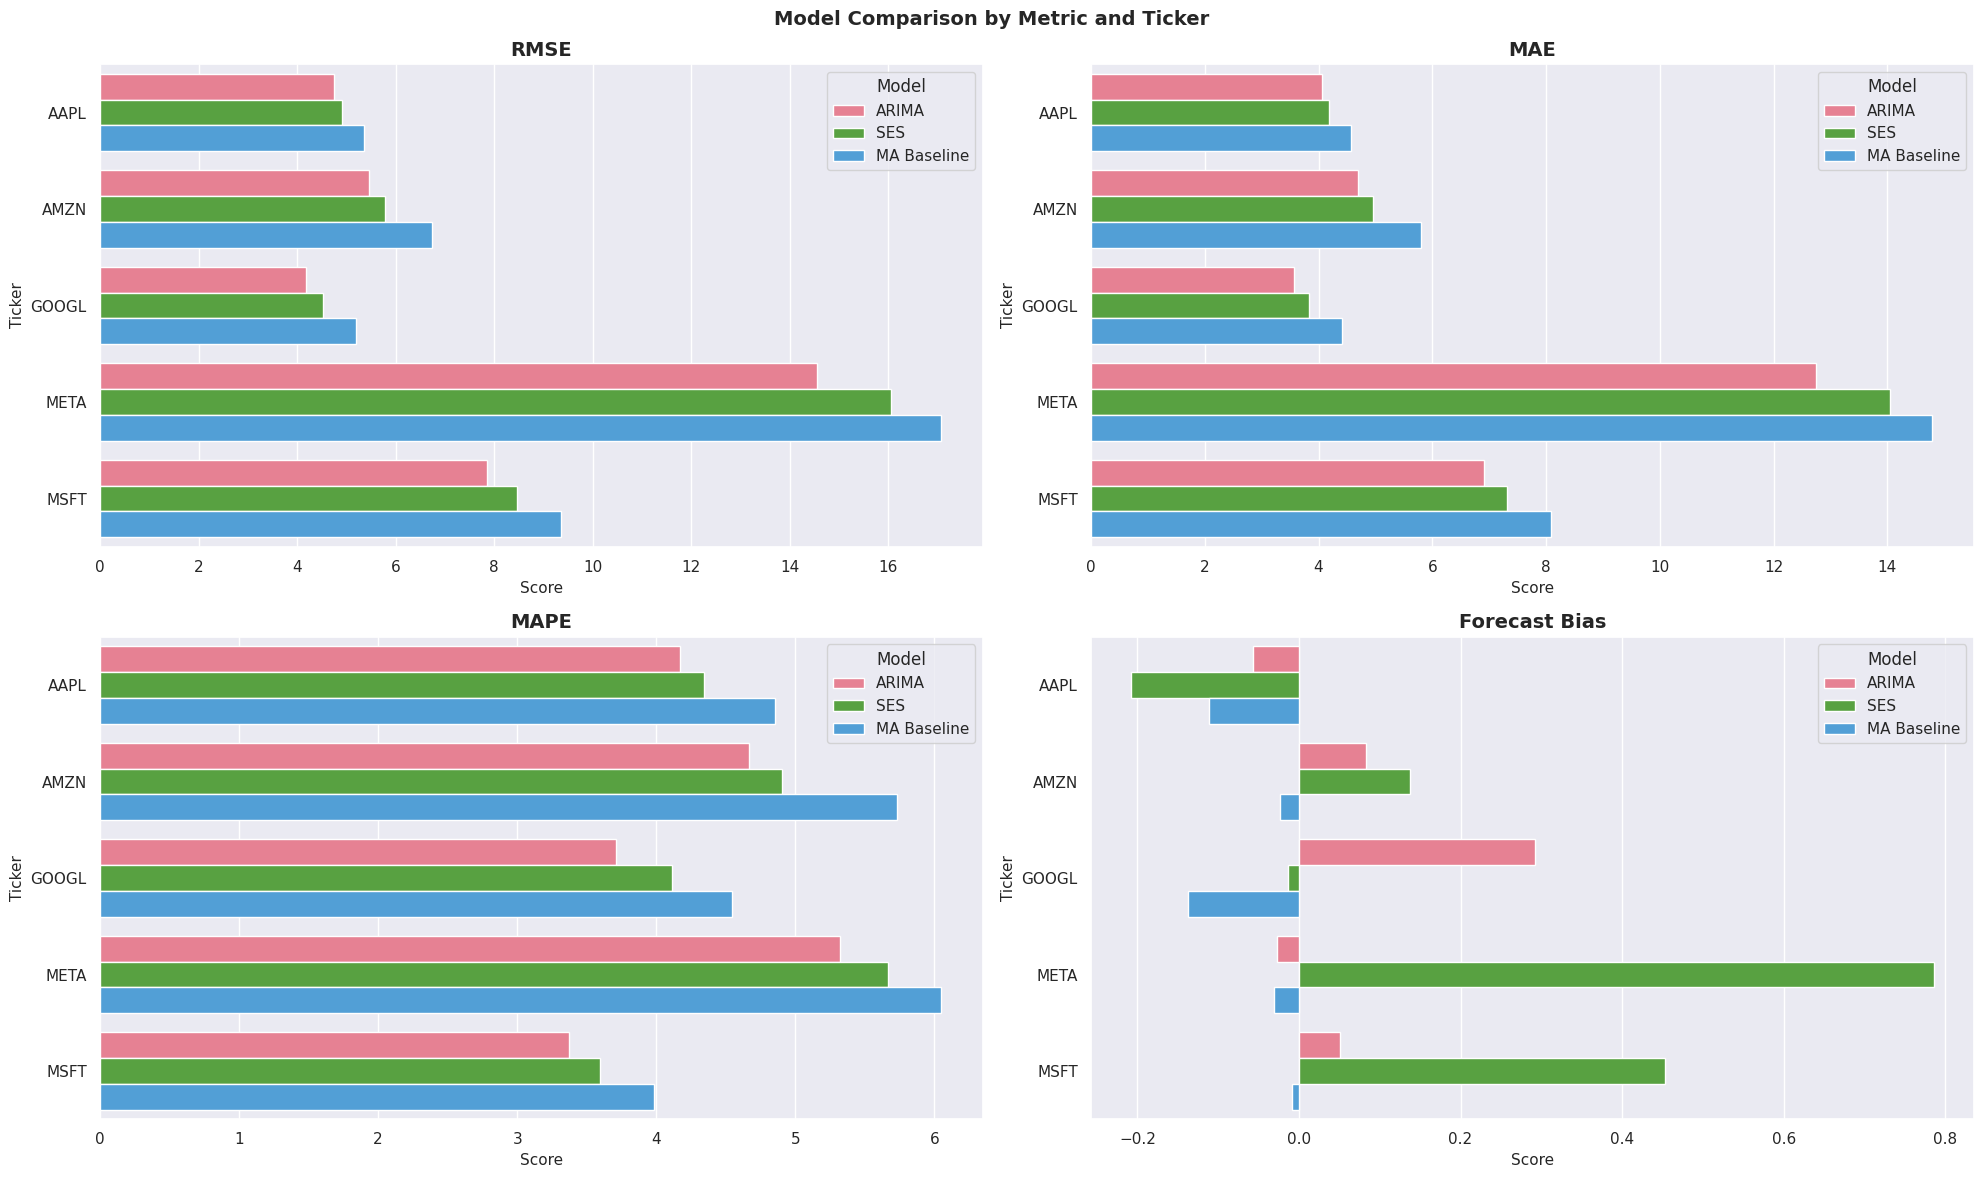

In [34]:
metrics = ["RMSE", "MAE", "MAPE", "Forecast Bias"]
fig, axes = plt.subplots(2, 2, figsize=(20, 12))
axes = axes.flatten()

for ax, metric in zip(axes, metrics):
    sns.barplot(
        data=results,
        y="Ticker",
        x=metric,
        hue="Model",
        ax=ax,
    )
    ax.set_title(metric)
    ax.set_xlabel("Score")
    ax.legend(title="Model", bbox_to_anchor=(1, 1))

plt.suptitle("Model Comparison by Metric and Ticker", fontsize=14)
plt.tight_layout()
plt.show()

ARIMA (seen in pink) & LGBM (green) compete very closely as the top 2 performing models across the board of metrics.

### Forecasting

With our strong performing XGB model, we can take a look at how the stock prices will be over the next month.

(Since XGB was constructed on difference-level per fold, it will need to be reconstructed upon plotting)

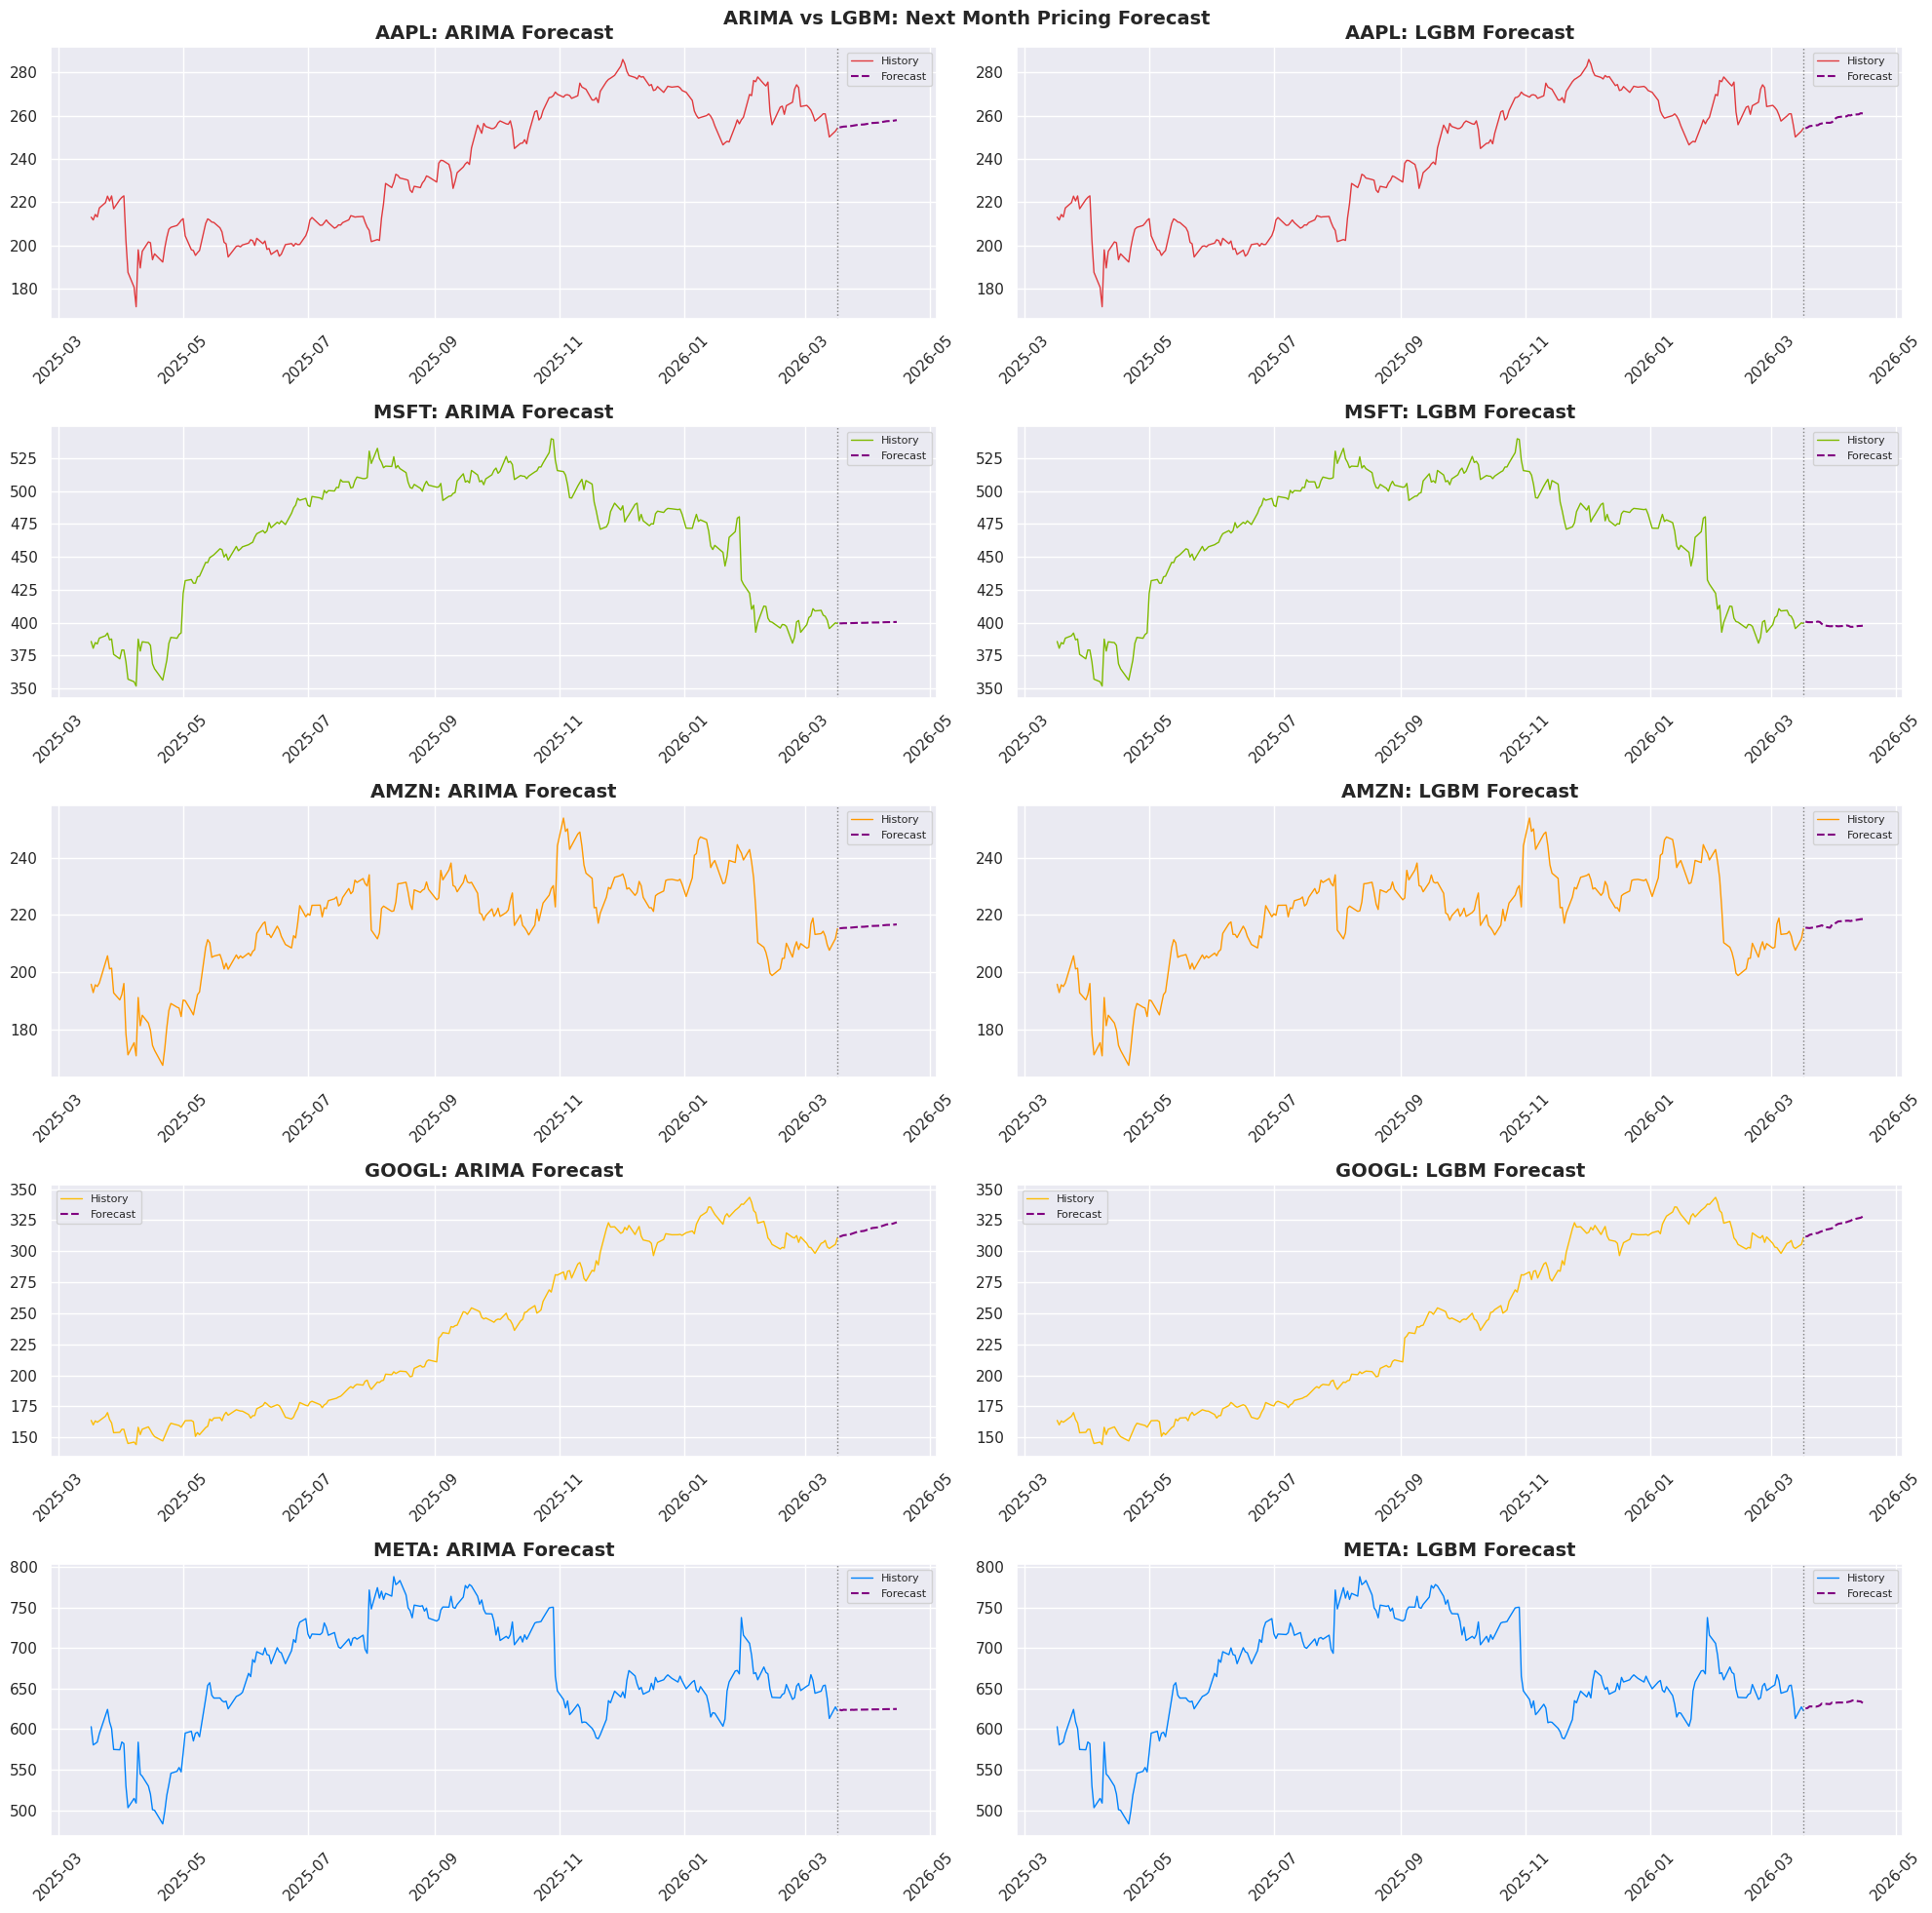

In [35]:
# removing leading NaN from computed differences
df_diff = df_close.diff().dropna()
df_close = df_close.loc[df_diff.index]

fig, axes = plt.subplots(len(tickers), 2, figsize=(20, 4 * len(tickers)))

for i, ticker in enumerate(tickers):
    # showing last year
    history = df_close[ticker].values[-252:]
    training_data = df_diff[ticker].values[-252:]
    anchor = df_close[ticker].iloc[-1]

    history_dates = df_close.index[-252:]
    last_date = history_dates[-1]
    future_dates = pd.bdate_range(start=last_date, periods=22)[1:]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ARIMA(training_data, order=(1, 0, 1)).fit()
    arima_preds = anchor + np.cumsum(model.forecast(steps=21))

    ax = axes[i][0]
    ax.plot(
        history_dates, history, color=logo_palette[ticker], linewidth=1, label="History"
    )
    ax.plot(
        future_dates,
        arima_preds,
        color="purple",
        linewidth=1.5,
        linestyle="--",
        label="Forecast",
    )
    ax.axvline(x=last_date, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ticker}: ARIMA Forecast")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

    _, lgbm_diff_preds = lgbm_model(
        training_data, testing_data=None, forecast_horizon=21
    )
    lgbm_preds = anchor + np.cumsum(lgbm_diff_preds)

    ax = axes[i][1]
    ax.plot(
        history_dates, history, color=logo_palette[ticker], linewidth=1, label="History"
    )
    ax.plot(
        future_dates,
        lgbm_preds,
        color="purple",
        linewidth=1.5,
        linestyle="--",
        label="Forecast",
    )
    ax.axvline(x=last_date, color="gray", linestyle=":", linewidth=1)
    ax.set_title(f"{ticker}: LGBM Forecast")
    ax.tick_params(axis="x", rotation=45)
    ax.legend(fontsize=8)

plt.suptitle(
    "ARIMA vs LGBM: Next Month Pricing Forecast", fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

In [36]:
next_day_preds = {}

for ticker in tickers:
    anchor = df_close[ticker].iloc[-1]
    training_data = df_diff[ticker].values[-252:]

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = ARIMA(training_data, order=(1, 0, 1)).fit()

    next_day_diff = model.forecast(steps=1)[0]
    next_day_preds[ticker] = anchor + next_day_diff

next_day_date = pd.bdate_range(start=df_close.index[-1], periods=2)[-1]

pd.Series(next_day_preds, name=f"Predicted Close ({next_day_date.date()})").round(2)

AAPL     254.53
MSFT     399.52
AMZN     215.34
GOOGL    311.65
META     624.11
Name: Predicted Close (2026-03-18), dtype: float64

In [37]:
def get_actual_close(tickers, date="2026-03-18"):
    if date is None:
        date = pd.Timestamp.today().normalize()
    else:
        date = pd.Timestamp(date)

    date_str = date.strftime("%Y-%m-%d")
    next_str = (date + pd.offsets.BDay(1)).strftime("%Y-%m-%d")

    data = yf.download(tickers, start=date_str, end=next_str, progress=False)
    return data["Close"].iloc[-1]


get_actual_close(tickers)

Ticker
AAPL     249.940002
AMZN     209.869995
GOOGL    307.690002
META     615.679993
MSFT     391.790009
Name: 2026-03-18 00:00:00, dtype: float64

## ⏱️ 5. Survival Analysis

> Using survival analysis methods, train models that are capable of predicting time to event (in this case event is ≥5% daily increase in stock price). Note: the model should be the same for all stocks. Evaluate its performance on each stock independently.

Event: ≥5% daily increase in stock price


1 if daily return is greater than or equal to 5%, else 0.

### Survival Data

In [38]:
rows = []

for ticker in tickers:
    returns = df["Return"][ticker].dropna().reset_index(drop=True)
    volatility = df["Volatility"][ticker].dropna().reset_index(drop=True)
    # Event threshold in log-return terms: ln(1.05)
    # 5% return inversed from log space
    event = (returns >= np.log(1.05)).astype(int)
    last_event_idx = -1

    for i in range(len(returns)):
        if event[i] == 1:
            duration = i - last_event_idx
            avg_vol = volatility[max(0, last_event_idx) : i].mean()

            rows.append(
                {
                    "ticker": ticker,
                    "duration": duration,
                    "event_observed": 1,
                    "avg_volatility": avg_vol,
                }
            )

            last_event_idx = i

    if last_event_idx < len(returns) - 1:
        duration = len(returns) - 1 - last_event_idx
        avg_vol = volatility[last_event_idx:].mean()

        rows.append(
            {
                "ticker": ticker,
                "duration": duration,
                "event_observed": 0,
                "avg_volatility": avg_vol,
            }
        )

survival_df = pd.DataFrame(rows)
survival_df.head()

,ticker,duration,event_observed,avg_volatility
0,AAPL,74,1,0.269543
1,AAPL,13,1,0.449997
2,AAPL,316,1,0.232844
3,AAPL,43,1,0.303078
4,AAPL,73,1,0.244978


### Kaplan-Meier Curves

Kaplan Meier to visualize

need durations 1 and event_observed 2 (1 or 0)

volatility series pulled from the df, avg_vol computed over each window, and "avg_volatility": avg_vol appended to each row.

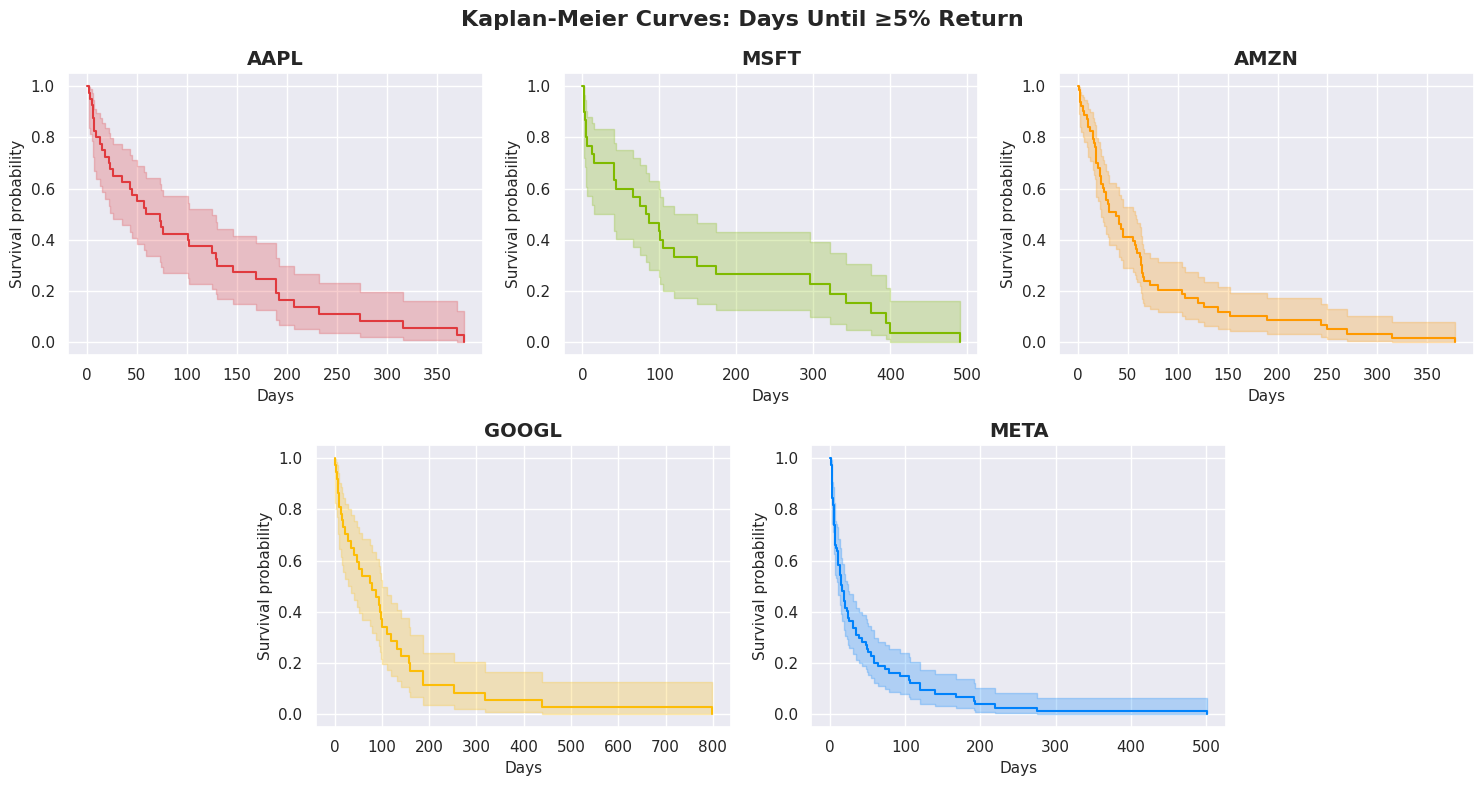

In [39]:
mosaic = """AABBCC
            .DDEE."""

fig, ax_dict = plt.subplot_mosaic(mosaic, figsize=(15, 8))

for ax_key, ticker in zip(ax_dict.keys(), survival_df["ticker"].unique()):
    subset = survival_df[survival_df["ticker"] == ticker]

    kmf = KaplanMeierFitter()
    kmf.fit(subset["duration"], subset["event_observed"], label=ticker)
    kmf.plot_survival_function(
        ax=ax_dict[ax_key], ci_show=True, color=logo_palette[ticker]
    )

    ax_dict[ax_key].set_title(ticker)
    ax_dict[ax_key].set_xlabel("Days")
    ax_dict[ax_key].set_ylabel("Survival probability")
    ax_dict[ax_key].legend().remove()

fig.suptitle("Kaplan-Meier Curves: Days Until ≥5% Return")
plt.tight_layout()
plt.show()

⚠️ META is censored

### Log-Rank Test

Determining if the survival curves seen above **differ significantly** between two or more groups

In [40]:
logrank_rows = []

for ticker_a, ticker_b in combinations(tickers, 2):
    a = survival_df[survival_df["ticker"] == ticker_a]
    b = survival_df[survival_df["ticker"] == ticker_b]

    results = logrank_test(
        a["duration"],
        b["duration"],
        event_observed_A=a["event_observed"],
        event_observed_B=b["event_observed"],
    )

    logrank_rows.append(
        {
            "ticker_a": ticker_a,
            "ticker_b": ticker_b,
            "p_value": round(results.p_value, 4),
        }
    )

logrank_df = pd.DataFrame(logrank_rows)

logrank_df_sorted = logrank_df.sort_values("p_value").reset_index(drop=True)

logrank_df_sorted.style.map(
    lambda val: f"color: {logo_palette.get(val, '')}", subset=["ticker_a", "ticker_b"]
).map(
    lambda val: "color: green; font-weight: 500" if val < 0.05 else "",
    subset=["p_value"],
).format(
    {"p_value": "{:.4f}"}
)

,ticker_a,ticker_b,p_value
0,MSFT,META,0.0009
1,AAPL,META,0.0014
2,GOOGL,META,0.0017
3,MSFT,AMZN,0.0049
4,AMZN,META,0.0412
5,AMZN,GOOGL,0.0498
6,AAPL,AMZN,0.0815
7,AAPL,MSFT,0.2110
8,MSFT,GOOGL,0.5255
9,AAPL,GOOGL,0.9675


### Cox Proportional Hazards Model

does higher volatility before an event reduce the waiting time to the next ≥5% day? Cox shines when you have continuous covariates (volatility, volume, market cap) that you want to control for or measure the effect of. With only ticker as a grouping variable, log-rank already answers the question.


In [41]:
survival_results = []

for ticker in tickers:
    ticker_df = (
        survival_df[survival_df["ticker"] == ticker][
            ["duration", "event_observed", "avg_volatility"]
        ]
        .dropna()
        .reset_index(drop=True)
    )

    scaler = StandardScaler()
    ticker_df["avg_volatility_scaled"] = scaler.fit_transform(
        ticker_df[["avg_volatility"]]
    )

    cox_df = ticker_df[["duration", "event_observed", "avg_volatility_scaled"]]

    cph = CoxPHFitter()
    cph.fit(cox_df, duration_col="duration", event_col="event_observed")
    ci = cph.concordance_index_

    times = np.percentile(ticker_df["duration"], np.linspace(5, 95, 50))
    surv_probs = cph.predict_survival_function(cox_df, times=times)

    brier_scores = []
    for t_idx, t in enumerate(times):
        s_t = surv_probs.iloc[t_idx].values
        died_by_t = (ticker_df["duration"].values <= t) & (
            ticker_df["event_observed"].values == 1
        )
        alive_at_t = ticker_df["duration"].values > t
        bs = (
            np.mean(s_t[died_by_t] ** 2) + np.mean((1 - s_t[alive_at_t]) ** 2)
            if (died_by_t.any() and alive_at_t.any())
            else np.nan
        )
        brier_scores.append(bs)

    ibs = np.nanmean(brier_scores)

    # time to event (median survival of last observation)
    # predict survival function for the last row (most recent window)
    last_obs = cox_df[["avg_volatility_scaled"]].iloc[[-1]]
    surv_func = cph.predict_survival_function(last_obs)

    # time to event = median survival time = when S(t) crosses 0.5
    time_to_event = (surv_func < 0.5).idxmax().values[0]

    survival_results.append(
        {
            "ticker": ticker,
            "time_to_event": time_to_event,
            "concordance_index": round(ci, 4),
            "brier_score": round(ibs, 4),
        }
    )

survival_results_df = pd.DataFrame(survival_results)
survival_results_df.sort_values("concordance_index", ascending=False).reset_index(
    drop=True
)

,ticker,time_to_event,concordance_index,brier_score
0,MSFT,119.0,0.8487,0.4354
1,GOOGL,159.0,0.8300,0.3554
2,AAPL,130.0,0.8110,0.4076
3,AMZN,66.0,0.7732,0.4144
4,META,48.0,0.7166,0.5336


* Time to Event: Amount of days until the next ≥5% simple return, given current volatility regime
* Concordance Index: how well volatility ranks the risk ordering
* Brier Score: calibration of predicted survival probabilities 

avg_volatility is the mean volatility over each window — so the Cox model estimates whether windows with higher volatility tend to see a ≥5% day sooner. A negative coefficient means higher volatility → shorter wait → higher hazard.

## 🥇 6. Ranking

> Build ranking model that is capable of ranking given stocks in descending order in terms of possible daily gains from each stock.

> Ranking Models

We construct a relative ranking of stocks at each time step based on predicted returns or risk-adjusted metrics. This supports portfolio allocation and decision-making strategies that prioritize the most promising assets at any given moment.


Ranking the 5 stocks by daily return 

* Objective: Rank the 5 stocks based on possible daily gains from each stock
* Model: LGb with lambdarank 
* Method: Pairwise
* Evaluation: NDCG & Predicted vs. Actual plot

* Query ID: Date
* Item ID: Ticker
* Features describing the Query-Item pair: Returns, Volume, Volatility
* Relevance label: Indicate based on returns how relevant it is for the query

In [42]:
rank_df = df.copy()
rank_df = rank_df.stack(level="Ticker", future_stack=True).reset_index()
rank_df = rank_df.dropna(subset=["Return", "Volatility"])

rank_df["Relevance"] = (
    rank_df.groupby("Date")["Return"]
    .rank(method="first", ascending=True)
    .sub(1)
    .astype(int)
)
rank_df.tail()

,Date,Ticker,Close,High,Low,Open,Volume,Return,Volatility,Relevance
20370,2026-03-17,AAPL,254.229996,255.130005,252.179993,252.960007,32361600.0,0.005562,0.236627,2
20371,2026-03-17,AMZN,215.199997,215.699997,212.429993,212.820007,44969900.0,0.016209,0.258090,3
20372,2026-03-17,GOOGL,310.920013,311.420013,305.500000,305.859985,21955200.0,0.017390,0.233990,4
20373,2026-03-17,META,622.659973,636.549988,621.700012,627.989990,10348800.0,-0.007663,0.271637,0
20374,2026-03-17,MSFT,399.410004,404.399994,397.750000,400.269989,26228300.0,-0.001351,0.221323,1


In [51]:
rank_df["ret_lag1"] = rank_df.groupby("Ticker")["Return"].shift(1)
rank_df["vol_lag1"] = rank_df.groupby("Ticker")["Volatility"].shift(1)

rank_df = rank_df.dropna(subset=["ret_lag1", "vol_lag1"])

X = rank_df[["ret_lag1", "vol_lag1"]]
y = rank_df["Relevance"]

groups = rank_df.groupby("Date").size().tolist()

train_data = lgb.Dataset(X, label=y, group=groups)

params = {
    "objective": "lambdarank",
    "metric": "ndcg",
    "ndcg_eval_at": [1, 3],
    "verbose": -1,
}

model = lgb.train(params, train_data, num_boost_round=100)

rank_df["Score"] = model.predict(X)
rank_df["pred_rank"] = (
    rank_df.groupby("Date")["Score"].rank(ascending=False).astype(int)
)
rank_df.tail()

/tmp/ipykernel_42939/3203708148.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rank_df["Score"] = model.predict(X)
/tmp/ipykernel_42939/3203708148.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rank_df["pred_rank"] = (


,Date,Ticker,Close,High,Low,Open,Volume,Return,Volatility,Relevance,Score,pred_rank,ret_lag1,vol_lag1
20370,2026-03-17,AAPL,254.229996,255.130005,252.179993,252.960007,32361600.0,0.005562,0.236627,2,0.096469,2,0.010737,0.248129
20371,2026-03-17,AMZN,215.199997,215.699997,212.429993,212.820007,44969900.0,0.016209,0.258090,3,-0.076937,4,0.019409,0.255326
20372,2026-03-17,GOOGL,310.920013,311.420013,305.500000,305.859985,21955200.0,0.017390,0.233990,4,0.097443,1,0.010792,0.229118
20373,2026-03-17,META,622.659973,636.549988,621.700012,627.989990,10348800.0,-0.007663,0.271637,0,0.073849,3,0.022997,0.275346
20374,2026-03-17,MSFT,399.410004,404.399994,397.750000,400.269989,26228300.0,-0.001351,0.221323,1,-0.205580,5,0.011062,0.221319


In [ ]:
rank_df["score"] = model.predict(X)
rank_df["pred_rank"] = (
    rank_df.groupby("Date")["score"].rank(ascending=False).astype(int)
)

print(
    rank_df[["Date", "Ticker", "Return", "relevance", "pred_rank"]]
    .sort_values(["Date", "pred_rank"])
    .head(20)
)

✅ Walk-forward
✅ LambdaRank model
✅ Ranking + IC + top-1

Actual vs predicted rank
NDCG score

## 7. Conclusion

Suggestions for Further Research:
- Alternative source from Yahoo Finance to a more well-known modern source for data
- Take into account the turbulence of the markets in recent times
- Attempt ensembling for forecasting for even more robust modelling and predictions.